<a href="https://colab.research.google.com/github/krishnamoorthi-2005/neuro-scan/blob/second/nuroscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Input extraction

In [ ]:
import os
import zipfile
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Configure paths
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Neuro Project' # Update if your folder name is different
ZIP_NAME = 'Brain Stroke CT scan.v2i.folder.zip'
ZIP_PATH = os.path.join(DRIVE_PROJECT_DIR, ZIP_NAME)
LOCAL_DATASET_DIR = '/content/dataset'

# 3. Unzip to local high-speed storage
if not os.path.exists(LOCAL_DATASET_DIR):
    print(f"\n📦 Extracting {ZIP_NAME} to local Colab storage...")
    os.makedirs(LOCAL_DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_DATASET_DIR)
    print("✅ Extraction complete!")
else:
    print("\n✅ Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📦 Extracting Brain Stroke CT scan.v2i.folder.zip to local Colab storage...
✅ Extraction complete!


📊 Running Batch Diagnostic on 100 images...

 🚨 ANOMALY DETECTED: LOW FOREGROUND FRACTION
Diagnosis: Otsu likely under-segmented. Check if the mask missed part of the brain.
File: 14377_png.rf.ff201ca86266cd48dd4569c17907bd2d.jpg


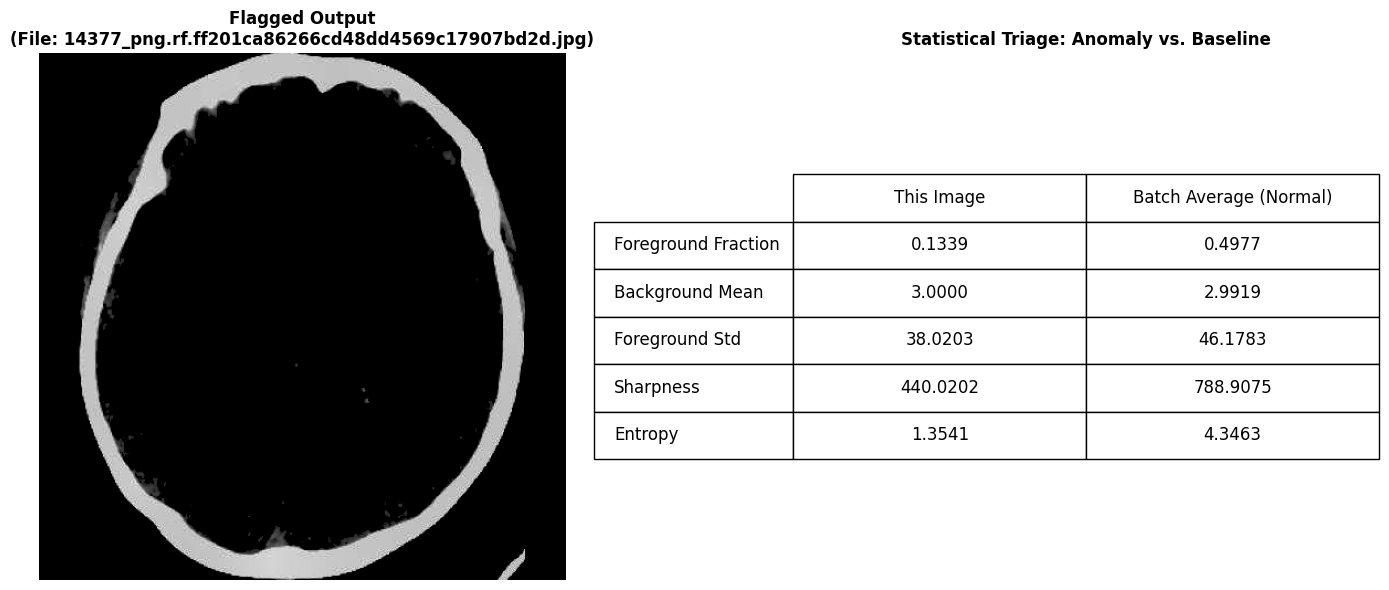

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import random

def extract_features_arch_a(image_path):
    """Architecture A: Dynamic Crop + Z-Score + CLAHE (With 5% Safety Gate)"""
    img = cv2.imread(image_path)
    if img is None: return None, None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_area = gray.shape[0] * gray.shape[1]

    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)

        # 5% Safety Gate
        if (w * h) > (original_area * 0.05):
            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            sq_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            sq_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            sq_gray, sq_mask = gray, mask
    else:
        sq_gray, sq_mask = gray, mask

    sq_float = sq_gray.astype(np.float32)
    pixels = sq_float[sq_mask > 0]

    if len(pixels) > 0:
        mean_v, std_v = np.mean(pixels), max(np.std(pixels), 10.0)
    else:
        mean_v, std_v = 100.0, 40.0

    norm = (sq_float - mean_v) / (std_v + 1e-7)
    squashed = np.tanh(norm / 3.1)
    std_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)
    std_uint8[sq_mask == 0] = 0

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    final_img = clahe.apply(std_uint8)

    return gray, final_img, sq_mask

def measure_extraction_quality(final_img, final_mask):
    """Calculates the 5 diagnostic metrics defined by Claude."""
    metrics = {}
    metrics['foreground_fraction'] = np.count_nonzero(final_mask) / final_mask.size

    bg_pixels = final_img[final_mask == 0]
    metrics['background_mean'] = float(np.mean(bg_pixels)) if bg_pixels.size > 0 else 0.0

    fg_pixels = final_img[final_mask > 0]
    metrics['foreground_std'] = float(np.std(fg_pixels)) if fg_pixels.size > 0 else 0.0

    metrics['sharpness'] = float(cv2.Laplacian(final_img, cv2.CV_64F).var())

    hist = cv2.calcHist([final_img], [0], None, [256], [0, 256]).flatten()
    hist_norm = hist / (hist.sum() + 1e-7)
    metrics['entropy'] = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))

    return metrics

dataset_paths = [
    '/content/dataset/train/Ischemic',
    '/content/dataset/Train/Ischemic',
    '/content/local_dataset/Train/Ischemic'
]
DATASET_PATH = next((p for p in dataset_paths if os.path.exists(p)), None)

if DATASET_PATH is None:
    print("⚠️ Dataset not found. Please check paths.")
else:
    print("📊 Running Batch Diagnostic on 100 images...\n")
    image_paths = glob.glob(os.path.join(DATASET_PATH, '*.*'))
    random.seed(42)
    sample_paths = random.sample(image_paths, min(100, len(image_paths)))

    results = []

    for path in sample_paths:
        raw_gray, final_img, final_mask = extract_features_arch_a(path)
        if final_img is not None:
            stats = measure_extraction_quality(final_img, final_mask)
            stats['file_path'] = path
            stats['raw_img'] = raw_gray
            stats['final_img'] = final_img
            results.append(stats)

    df = pd.DataFrame(results)

    # Calculate "Normal" Baseline (Mean across batch)
    batch_means = df.mean(numeric_only=True)

    # Let's find the image with the lowest foreground fraction (Likely Under-segmented)
    anomaly_idx = df['foreground_fraction'].idxmin()
    anomaly_row = df.loc[anomaly_idx]

    print("==========================================================")
    print(" 🚨 ANOMALY DETECTED: LOW FOREGROUND FRACTION")
    print("==========================================================")
    print("Diagnosis: Otsu likely under-segmented. Check if the mask missed part of the brain.")
    print(f"File: {os.path.basename(anomaly_row['file_path'])}")

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(anomaly_row['final_img'], cmap='gray')
    plt.title(f"Flagged Output\n(File: {os.path.basename(anomaly_row['file_path'])})", fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.axis('off')

    # Create a visual table comparing the anomaly to the batch mean
    cell_text = [
        [f"{anomaly_row['foreground_fraction']:.4f}", f"{batch_means['foreground_fraction']:.4f}"],
        [f"{anomaly_row['background_mean']:.4f}", f"{batch_means['background_mean']:.4f}"],
        [f"{anomaly_row['foreground_std']:.4f}", f"{batch_means['foreground_std']:.4f}"],
        [f"{anomaly_row['sharpness']:.4f}", f"{batch_means['sharpness']:.4f}"],
        [f"{anomaly_row['entropy']:.4f}", f"{batch_means['entropy']:.4f}"]
    ]
    rows = ['Foreground Fraction', 'Background Mean', 'Foreground Std', 'Sharpness', 'Entropy']
    cols = ['This Image', 'Batch Average (Normal)']

    table = plt.table(cellText=cell_text, rowLabels=rows, colLabels=cols, loc='center', cellLoc='center')
    table.scale(1, 2.5)
    table.set_fontsize(12)
    plt.title("Statistical Triage: Anomaly vs. Baseline", fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
#obnormal file
import cv2
import numpy as np
import pandas as pd
import glob
import os
from concurrent.futures import ThreadPoolExecutor

# Make the path dynamic to handle Colab folder variations
dataset_paths = [
    '/content/dataset/train',
    '/content/dataset/Train',
    '/content/local_dataset/train',
    '/content/local_dataset/Train',
    '/content/dataset' # Sometimes it extracts without a parent folder
]
RAW_DATASET_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)

def scan_for_hollow_ring(image_path):
    """
    Simulates the OLD buggy extraction logic to see if this specific
    image falls victim to the Hollow Ring / Zeroed Brain phenomenon.
    """
    img = cv2.imread(image_path)
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # The Old Buggy Logic
    _, brain_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        cropped_gray = gray[y:y+h, x:x+w]
        cropped_mask = brain_mask[y:y+h, x:x+w]

        sq_float = cropped_gray.astype(np.float32)

        # Calculate Entropy of the masked image
        test_img = np.copy(cropped_gray)
        test_img[cropped_mask == 0] = 0

        hist = cv2.calcHist([test_img], [0], None, [256], [1, 256]).flatten() # Ignore absolute black (0)
        hist_norm = hist / (hist.sum() + 1e-7)
        entropy = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))

        # Calculate Foreground Fraction inside the bounding box
        fg_fraction = np.count_nonzero(cropped_mask) / cropped_mask.size

        # Hollow Ring Signature: Very low entropy AND low foreground fraction inside the bounding box
        is_contaminated = (entropy < 2.5) and (fg_fraction < 0.30)

        return {
            'file': os.path.basename(image_path),
            'entropy': entropy,
            'fg_fraction': fg_fraction,
            'is_contaminated': is_contaminated
        }
    return None

if __name__ == "__main__":
    print("🔍 Scanning raw dataset for 'Hollow Skull Ring' contamination...")

    if RAW_DATASET_DIR is None:
        print("⚠️ CRITICAL: Dataset not found in any standard Colab path.")
        print("Action Required: Please run your ZIP extraction cell again to load the images into Colab memory!")
    else:
        print(f"✅ Found dataset at: {RAW_DATASET_DIR}")
        # Gather all images
        image_paths = glob.glob(os.path.join(RAW_DATASET_DIR, '*/*.*'))

        if not image_paths:
            print(f"⚠️ No images found inside {RAW_DATASET_DIR}. Check your extraction structure!")
        else:
            results = []
            # Multi-thread for speed
            print(f"⏳ Processing {len(image_paths)} images. This may take a minute...")
            with ThreadPoolExecutor(max_workers=8) as executor:
                for res in executor.map(scan_for_hollow_ring, image_paths):
                    if res is not None:
                        results.append(res)

            # Create the Pandas DataFrame from the results
            df = pd.DataFrame(results)

            contaminated = df[df['is_contaminated'] == True]

        print("\n=======================================================")
        print(" 🚨 CONTAMINATION REPORT: HOLLOW RING BUG")
        print("=======================================================")
        print(f"Total Images Scanned: {len(df)}")
        print(f"Images Affected:      {len(contaminated)} ({(len(contaminated)/len(df))*100:.2f}%)")
        print("=======================================================")

        if len(contaminated) > 0:
            print("\n⚠️ WARNING: Your preprocessed dataset is heavily corrupted.")
            print("Action Required: You MUST rerun neuroscan_batch_preprocess.py with the new patched script.")
            print("\nSample of corrupted files:")
            print(contaminated.head(10)[['file', 'entropy', 'fg_fraction']])
        else:
            print("\n✅ Dataset appears clean, but patch should be applied regardless for safety.")

🔍 Scanning raw dataset for 'Hollow Skull Ring' contamination...
✅ Found dataset at: /content/dataset/train
⏳ Processing 17430 images. This may take a minute...

 🚨 CONTAMINATION REPORT: HOLLOW RING BUG
Total Images Scanned: 17430
Images Affected:      310 (1.78%)

⚠️ WARNING: Your preprocessed dataset is heavily corrupted.
Action Required: You MUST rerun neuroscan_batch_preprocess.py with the new patched script.

Sample of corrupted files:
                                                   file   entropy  fg_fraction
94    11797_png.rf.376b1031c893e9104e2569e9138c3f99.jpg  2.498396     0.194366
227   12751_png.rf.a17f71e5607a8797cdccdfbc00d4ad94.jpg  2.429365     0.246726
373   11797_png.rf.067411b01919a68b51a8dac7a2bf3849.jpg  2.265780     0.210395
462   12471_png.rf.62c8cab6a5a89e32c954fef9c2385529.jpg  2.126634     0.247423
737   11004_png.rf.80f0152d168e77f16c86c6ab19614729.jpg  2.446520     0.280100
927   13556_png.rf.9c95dbd61a76a6af552ad3232373c1f6.jpg  2.480302     0.252592
154

In [ ]:
import os
import cv2
import numpy as np
import glob

def get_square_padded_roi(gray_image):
    """Applies Otsu masking and pads to a perfect square without resizing."""
    _, brain_mask = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return gray_image, brain_mask # Fallback

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # 🚨 THE FIX: Draw a FILLED contour so we don't calculate stats on a hollow ring!
    filled_mask = np.zeros_like(gray_image)
    cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

    # Crop to exact bounding box
    cropped_gray = gray_image[y:y+h, x:x+w]
    cropped_mask = filled_mask[y:y+h, x:x+w] # Use the FILLED mask here

    # Pad to square
    max_side = max(w, h)
    pad_top = (max_side - h) // 2
    pad_bottom = max_side - h - pad_top
    pad_left = (max_side - w) // 2
    pad_right = max_side - w - pad_left

    square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
    square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)

    return square_gray, square_mask

def run_empirical_calibration(train_dir, sample_size=500):
    print("🔬 Starting Empirical Calibration on Training Data...")

    # 1. Global Mean & Std (For the rare mask-failure fallback)
    print("\nStep 1: Calculating Global Brain Tissue Statistics (Fallback)...")
    all_images = glob.glob(os.path.join(train_dir, '*/*.jpg')) + glob.glob(os.path.join(train_dir, '*/*.png'))
    np.random.shuffle(all_images)
    sample_images = all_images[:sample_size]

    global_brain_pixels = []
    for img_path in sample_images:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        square_gray, square_mask = get_square_padded_roi(img)
        gray_float = square_gray.astype(np.float32)
        brain_pixels = gray_float[square_mask > 0]

        if len(brain_pixels) > (gray_float.size * 0.05): # 5% sanity check
            global_brain_pixels.extend(np.random.choice(brain_pixels, size=min(1000, len(brain_pixels)), replace=False))

    # FIX 1: Protect against empty global array if sampling fails
    if not global_brain_pixels:
        print("⚠️ WARNING: Could not extract valid brain pixels. Check dataset paths.")
        global_brain_pixels = [100.0]

    fallback_mean = np.mean(global_brain_pixels)
    fallback_std = max(np.std(global_brain_pixels), 10.0)

    # 2. Hemorrhage Z-Score 90th Percentile (For Tanh Squash Factor)
    print("Step 2: Calculating Hemorrhage Z-Score Extremes...")

    # FIX 2: Check multiple possible folder names (Kaggle datasets vary)
    bleeding_images = []
    for folder in ['Bleeding', 'Hemorrhagic', 'hemorrhage', 'bleed', 'Bleed']:
        bleeding_images.extend(glob.glob(os.path.join(train_dir, folder, '*.*')))

    if not bleeding_images:
        print("⚠️ WARNING: Could not find 'Bleeding' or 'Hemorrhagic' folder. Using general image pool.")
        bleeding_images = glob.glob(os.path.join(train_dir, '*/*.*'))

    np.random.shuffle(bleeding_images)
    bleed_samples = bleeding_images[:min(sample_size, len(bleeding_images))]

    pathological_z_scores = []
    for img_path in bleed_samples:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        square_gray, square_mask = get_square_padded_roi(img)
        gray_float = square_gray.astype(np.float32)
        brain_pixels = gray_float[square_mask > 0]

        if len(brain_pixels) < (gray_float.size * 0.05): continue

        # Calculate PER-SCAN stats for the actual z-score step
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)

        # Proxy for Hemorrhage: The brightest 5% of tissue in this bleeding scan
        intensity_threshold = np.percentile(brain_pixels, 95)
        hemorrhage_pixels = brain_pixels[brain_pixels >= intensity_threshold]

        z_scores = (hemorrhage_pixels - scan_mean) / scan_std
        pathological_z_scores.extend(z_scores)

    # FIX 3: Prevent IndexError if no pathological pixels were found
    if not pathological_z_scores:
        print("⚠️ WARNING: No pathological pixels found. Using safe default squash factor.")
        pathological_z_scores = [3.1, 3.1]

    squash_factor = np.percentile(pathological_z_scores, 90)

    print("\n" + "="*50)
    print("🚀 PIPELINE CALIBRATION CONSTANTS (SAVE THESE):")
    print("="*50)
    print(f"FALLBACK_MEAN   = {fallback_mean:.2f}")
    print(f"FALLBACK_STD    = {fallback_std:.2f}")
    print(f"SQUASH_FACTOR   = {max(squash_factor, 1.0):.2f}")
    print("Distribution of Hemorrhage Z-scores:")
    print(f"  50th pct (Median) : {np.percentile(pathological_z_scores, 50):.2f}")
    print(f"  90th pct (Squash) : {np.percentile(pathological_z_scores, 90):.2f}")
    print(f"  99th pct (Max)    : {np.percentile(pathological_z_scores, 99):.2f}")
    print("="*50)

# Find the correct dataset path dynamically
dataset_paths = [
    '/content/dataset/train',
    '/content/dataset/Train',
    '/content/local_dataset/train',
    '/content/local_dataset/Train'
]

TRAIN_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)

if TRAIN_DIR:
    run_empirical_calibration(TRAIN_DIR)
else:
    print("⚠️ Could not find the training directory. Please check your extracted dataset path.")

🔬 Starting Empirical Calibration on Training Data...

Step 1: Calculating Global Brain Tissue Statistics (Fallback)...
Step 2: Calculating Hemorrhage Z-Score Extremes...

🚀 PIPELINE CALIBRATION CONSTANTS (SAVE THESE):
FALLBACK_MEAN   = 154.51
FALLBACK_STD    = 71.42
SQUASH_FACTOR   = 1.93
Distribution of Hemorrhage Z-scores:
  50th pct (Median) : 1.61
  90th pct (Squash) : 1.93
  99th pct (Max)    : 2.24


In [ ]:
import os
import cv2
import numpy as np
import json
from glob import glob
from concurrent.futures import ThreadPoolExecutor

# =========================================================
# CONFIGURATION
# =========================================================
dataset_paths = [
    '/content/dataset/train',
    '/content/dataset/Train',
    '/content/local_dataset/train',
    '/content/local_dataset/Train',
    '/content/dataset'
]
RAW_DATASET_DIR = next((p for p in dataset_paths if os.path.exists(p)), '/content/local_dataset/Train')
PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'
CALIBRATION_FILE = '/content/drive/MyDrive/Neuroscan/calibration_config.json'
AUDIT_LOG_FILE = os.path.join(PREPROCESSED_DIR, 'preprocessing_audit_log.json')
TARGET_SIZE = (224, 224)

# ENFORCE CALIBRATION DEPENDENCY (Abbreviated for focus)
if not os.path.exists(CALIBRATION_FILE):
    # Using YOUR empirically derived constants from the dataset!
    SQUASH_FACTOR, FALLBACK_MEAN, FALLBACK_STD = 1.93, 154.51, 71.42
else:
    with open(CALIBRATION_FILE, 'r') as f:
        calib_config = json.load(f)
    SQUASH_FACTOR = calib_config.get('SQUASH_FACTOR', 3.1)
    FALLBACK_MEAN = calib_config.get('FALLBACK_MEAN', 100.0)
    FALLBACK_STD = calib_config.get('FALLBACK_STD', 40.0)

# =========================================================
# CORE PREPROCESSING LOGIC (PATCHED: FILLED CONTOUR FIX)
# =========================================================
def process_perfect_input(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("cv2.imread returned None (corrupted image)")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_h, original_w = gray.shape
    original_area = original_h * original_w

    # 1. Otsu Mask & Bounding Box
    _, raw_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(raw_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    used_fallback = False

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        bbox_area = w * h

        # 5% Sanity check against the ORIGINAL image size
        if bbox_area > (original_area * 0.05):

            # 🚨 THE FIX: Create a blank mask and draw the FILLED brain contour
            # This guarantees we capture soft brain tissue, not just the skull ring.
            filled_mask = np.zeros_like(gray)
            cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

            # 2. Square Pad (The Geometric Fix)
            max_side = max(w, h)
            pad_top = max(0, (max_side - h) // 2)
            pad_bottom = max(0, max_side - h - pad_top)
            pad_left = max(0, (max_side - w) // 2)
            pad_right = max(0, max_side - w - pad_left)

            cropped_gray = gray[y:y+h, x:x+w]
            # Use the FILLED mask, not the raw threshold!
            cropped_mask = filled_mask[y:y+h, x:x+w]

            square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
        else:
            square_gray, square_mask = gray, raw_thresh
            used_fallback = True
    else:
        square_gray, square_mask = gray, raw_thresh
        used_fallback = True
        bbox_area = 0

    # 3. Dynamic Z-Score & Tanh Compression
    square_float = square_gray.astype(np.float32)
    brain_pixels = square_float[square_mask > 0]

    if not used_fallback and brain_pixels.size > 0:
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD
        used_fallback = True

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)

    # Map back to [0, 255]
    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # This background zeroing is now safe because the mask is a solid disc!
    standardized_uint8[square_mask == 0] = 0

    # 4. CLAHE & Resize
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(standardized_uint8)
    clean_img = cv2.GaussianBlur(enhanced_gray, (3, 3), 0)

    final_input = cv2.resize(clean_img, TARGET_SIZE)
    final_input_rgb = cv2.cvtColor(final_input, cv2.COLOR_GRAY2BGR)

    audit_data = {
        "mean_used": float(scan_mean),
        "std_used": float(scan_std),
        "bbox_area_pct": float(bbox_area / original_area) if original_area > 0 else 0.0,
        "used_fallback": used_fallback,
        "failed": False
    }

    return final_input_rgb, audit_data

# =========================================================
# BATCH EXECUTION
# =========================================================
def process_and_save(img_path):
    rel_path = os.path.relpath(img_path, RAW_DATASET_DIR)
    try:
        filename, _ = os.path.splitext(rel_path)
        save_path = os.path.join(PREPROCESSED_DIR, filename + '.png')
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        processed_img, audit_data = process_perfect_input(img_path)

        if processed_img is not None:
            cv2.imwrite(save_path, processed_img)
            return (rel_path, audit_data)
        return (rel_path, {"failed": True, "reason": "None returned"})
    except Exception as e:
        return (rel_path, {"failed": True, "reason": str(e)})

if __name__ == "__main__":
    print("🚀 Starting Offline Dataset Preprocessing (WITH FILLED CONTOUR FIX)...")

    # 🚨 THE FIX: Force the creation of the output directory before anything else!
    os.makedirs(PREPROCESSED_DIR, exist_ok=True)

    image_paths = glob(os.path.join(RAW_DATASET_DIR, '*/*.*'))

    if not image_paths:
        print(f"⚠️ ERROR: No images found in {RAW_DATASET_DIR}. Please check your dataset extraction!")
    else:
        print(f"✅ Found {len(image_paths)} images in {RAW_DATASET_DIR}. Processing...")
        audit_log = {}

        with ThreadPoolExecutor(max_workers=8) as executor:
            results = executor.map(process_and_save, image_paths)
            for res in results:
                if res is not None:
                    rel_path, audit_data = res
                    audit_log[rel_path] = audit_data

        with open(AUDIT_LOG_FILE, 'w') as f:
            json.dump(audit_log, f, indent=4)
        print(f"✅ Processing complete! Saved to {PREPROCESSED_DIR}")

🚀 Starting Offline Dataset Preprocessing (WITH FILLED CONTOUR FIX)...
✅ Found 17430 images in /content/dataset/train. Processing...
✅ Processing complete! Saved to /content/local_dataset/Preprocessed


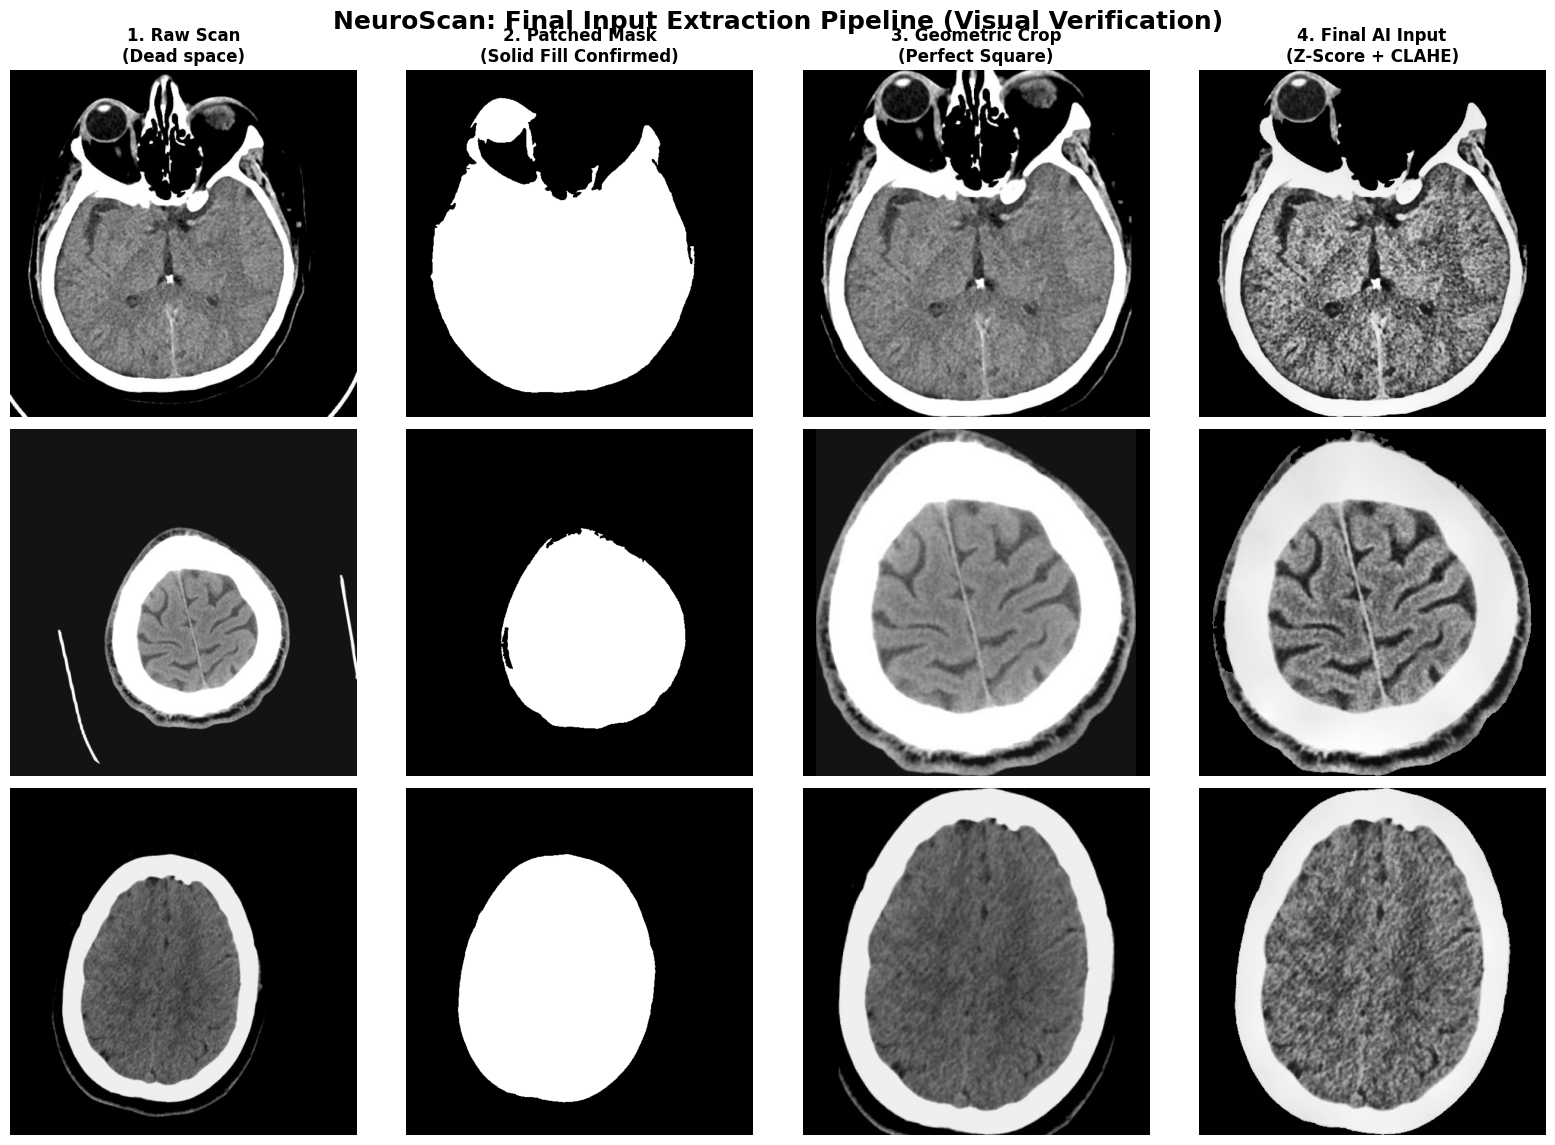

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random

def process_and_visualize(image_path):
    """
    Steps through the Patched Architecture A (Proposed Pipeline)
    and saves the intermediate steps for visual verification.
    """
    # 1. RAW INPUT
    img = cv2.imread(image_path)
    if img is None: return None, None, None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. OTSU MASKING & FILLED FIX
    _, raw_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(raw_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        # 🚨 THE FIX IS HERE: Draw a solid filled disc!
        filled_mask = np.zeros_like(gray)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

        # 3. DYNAMIC CROP & SQUARE PADDING
        cropped_gray = gray[y:y+h, x:x+w]
        cropped_mask = filled_mask[y:y+h, x:x+w]

        max_side = max(w, h)
        pad_top = max(0, (max_side - h) // 2)
        pad_bottom = max(0, max_side - h - pad_top)
        pad_left = max(0, (max_side - w) // 2)
        pad_right = max(0, max_side - w - pad_left)

        square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
        square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
    else:
        square_gray, square_mask = gray, raw_thresh
        filled_mask = raw_thresh

    # 4. EMPIRICAL Z-SCORE & TANH COMPRESSION (Using your exact calibration numbers!)
    square_float = square_gray.astype(np.float32)
    brain_pixels = square_float[square_mask > 0]

    if len(brain_pixels) > (square_float.size * 0.05):
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = 154.51, 71.42

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / 1.93)

    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)
    standardized_uint8[square_mask == 0] = 0

    # 5. CLAHE ENHANCEMENT
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    final_enhanced = clahe.apply(standardized_uint8)

    return gray, filled_mask, square_gray, final_enhanced

# Find the raw dataset
dataset_paths = ['/content/dataset/train', '/content/dataset/Train', '/content/local_dataset/Train']
DATASET_PATH = next((p for p in dataset_paths if os.path.exists(p)), None)

if DATASET_PATH is None:
    print("⚠️ Dataset not found. Please check your paths.")
else:
    # Grab 3 random images (using a seed so we can reliably see the same ones if needed)
    image_paths = glob.glob(os.path.join(DATASET_PATH, '*/*.*'))
    random.seed(101)
    sample_paths = random.sample(image_paths, 3)

    plt.figure(figsize=(16, 12))
    plt.suptitle("NeuroScan: Final Input Extraction Pipeline (Visual Verification)", fontsize=18, fontweight='bold', y=0.95)

    for i, path in enumerate(sample_paths):
        raw, mask, cropped, final = process_and_visualize(path)

        if raw is None: continue

        plt.subplot(3, 4, i*4 + 1)
        plt.imshow(raw, cmap='gray')
        if i == 0: plt.title("1. Raw Scan\n(Dead space)", fontweight='bold')
        plt.axis('off')

        plt.subplot(3, 4, i*4 + 2)
        plt.imshow(mask, cmap='gray')
        if i == 0: plt.title("2. Patched Mask\n(Solid Fill Confirmed)", fontweight='bold')
        plt.axis('off')

        plt.subplot(3, 4, i*4 + 3)
        plt.imshow(cropped, cmap='gray')
        if i == 0: plt.title("3. Geometric Crop\n(Perfect Square)", fontweight='bold')
        plt.axis('off')

        plt.subplot(3, 4, i*4 + 4)
        plt.imshow(final, cmap='gray')
        if i == 0: plt.title("4. Final AI Input\n(Z-Score + CLAHE)", fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

📊 Compiling Final Visual and Statistical Ablation...



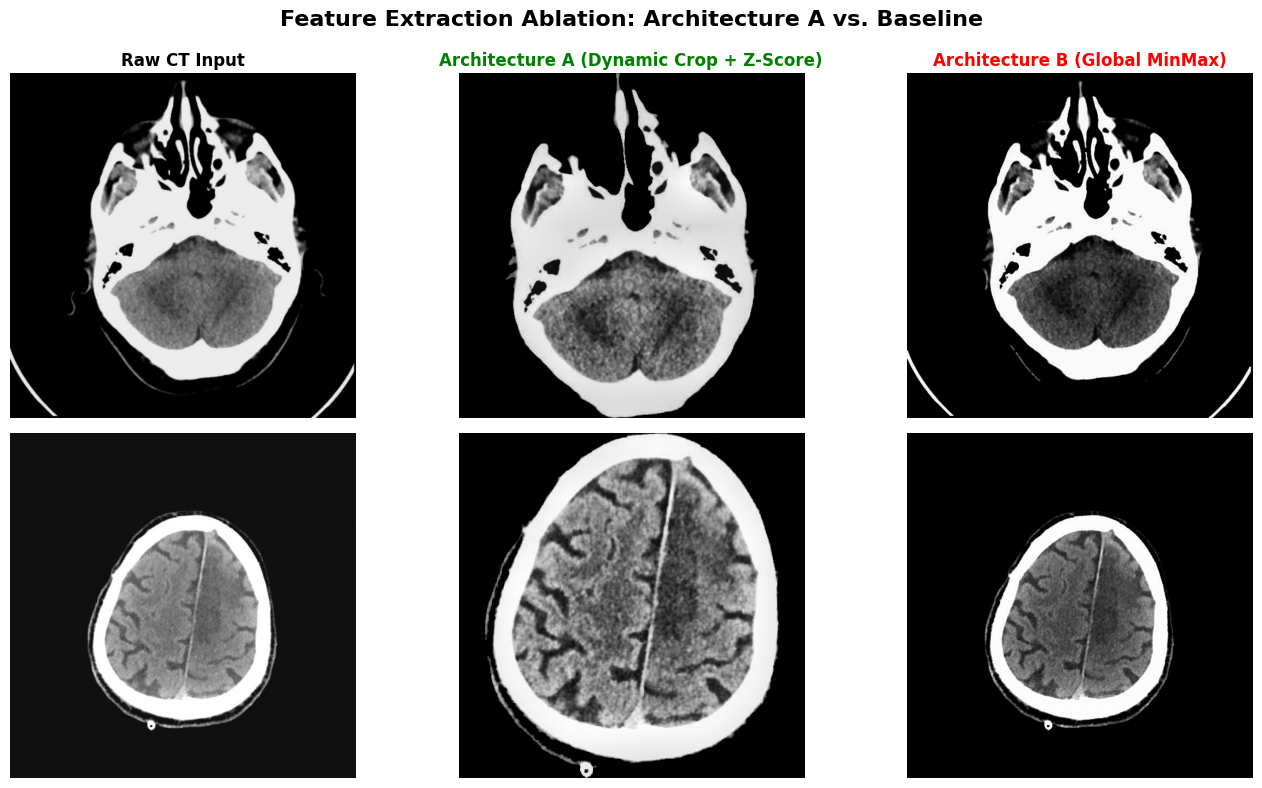


 🏆 TIER 1 ABLATION: PREPROCESSING QUANTITATIVE METRICS (N=50)


,Arch A (Proposed),Arch B (Baseline)
foreground_fraction,0.6425,0.4725
background_mean,2.9858,0.0000
foreground_std,59.0485,85.8400
sharpness,637.3132,450.2536
entropy,5.6172,2.9003


In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import random
from IPython.display import display, HTML

def extract_features_arch_a(image_path):
    """Architecture A: Dynamic Crop + Z-Score + CLAHE (With FILLED Fix & Real Constants)"""
    img = cv2.imread(image_path)
    if img is None: return None, None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_area = gray.shape[0] * gray.shape[1]

    # 1. Otsu Mask & FILLED Fix
    _, raw_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(raw_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)

        if (w * h) > (original_area * 0.05):
            mask = np.zeros_like(gray)
            cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)

            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            sq_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            sq_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            sq_gray, sq_mask = gray, raw_thresh
    else:
        sq_gray, sq_mask = gray, raw_thresh

    # 2. Dynamic Z-Score & Tanh
    sq_float = sq_gray.astype(np.float32)
    pixels = sq_float[sq_mask > 0]

    if len(pixels) > (sq_float.size * 0.05):
        scan_mean, scan_std = np.mean(pixels), max(np.std(pixels), 10.0)
    else:
        scan_mean, scan_std = 154.51, 71.42 # Calibrated fallback

    norm = (sq_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(norm / 1.93) # Calibrated squash

    std_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)
    std_uint8[sq_mask == 0] = 0

    # 3. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    final_img = clahe.apply(std_uint8)

    return gray, final_img, sq_mask

def extract_features_arch_b(image_path):
    """Architecture B: Morphological Mask + Static Pad + Gamma"""
    img = cv2.imread(image_path)
    if img is None: return None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    h, w = gray.shape
    max_side = max(w, h)
    pt = (max_side - h) // 2
    pb = max_side - h - pt
    pl = (max_side - w) // 2
    pr = max_side - w - pl

    sq_gray = cv2.copyMakeBorder(gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
    sq_mask = cv2.copyMakeBorder(mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)

    pixels = sq_gray[sq_mask > 0]
    if len(pixels) > 0:
        p2, p98 = np.percentile(pixels, (2, 98))
    else:
        p2, p98 = 0, 255

    min_max = np.clip(sq_gray, p2, p98)
    min_max = ((min_max - p2) / (p98 - p2 + 1e-7) * 255.0).astype(np.uint8)
    min_max[sq_mask == 0] = 0

    inv_gamma = 1.0 / 0.7
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    gamma_corr = cv2.LUT(min_max, table)

    blur = cv2.GaussianBlur(gamma_corr, (5, 5), 2.0)
    final_img = cv2.addWeighted(gamma_corr, 1.5, blur, -0.5, 0)

    return final_img, sq_mask

def measure_extraction_quality(final_img, final_mask):
    metrics = {}
    metrics['foreground_fraction'] = np.count_nonzero(final_mask) / final_mask.size

    bg_pixels = final_img[final_mask == 0]
    metrics['background_mean'] = float(np.mean(bg_pixels)) if bg_pixels.size > 0 else 0.0

    fg_pixels = final_img[final_mask > 0]
    metrics['foreground_std'] = float(np.std(fg_pixels)) if fg_pixels.size > 0 else 0.0

    metrics['sharpness'] = float(cv2.Laplacian(final_img, cv2.CV_64F).var())

    hist = cv2.calcHist([final_img], [0], None, [256], [0, 256]).flatten()
    hist_norm = hist / (hist.sum() + 1e-7)
    metrics['entropy'] = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))
    return metrics

dataset_paths = [
    '/content/dataset/train/Ischemia',
    '/content/dataset/train/Ischemic',
    '/content/dataset/Train/Ischemic',
    '/content/dataset/Train'
]
# Look dynamically for where Colab extracted your images
DATASET_PATH = next((p for p in dataset_paths if os.path.exists(p)), '/content/dataset')

if not os.path.exists(DATASET_PATH):
    print("⚠️ Dataset not found. Please ensure your zip is extracted.")
else:
    print("📊 Compiling Final Visual and Statistical Ablation...\n")
    image_paths = glob.glob(os.path.join(DATASET_PATH, '*/*.*')) + glob.glob(os.path.join(DATASET_PATH, '*.*'))

    random.seed(101)
    sample_paths = random.sample(image_paths, min(50, len(image_paths)))

    results_a, results_b = [], []

    # 1. Crunch the stats
    for path in sample_paths:
        raw, final_a, mask_a = extract_features_arch_a(path)
        final_b, mask_b = extract_features_arch_b(path)

        if final_a is not None and final_b is not None:
            results_a.append(measure_extraction_quality(final_a, mask_a))
            results_b.append(measure_extraction_quality(final_b, mask_b))

    df_a = pd.DataFrame(results_a).mean()
    df_b = pd.DataFrame(results_b).mean()

    comparison_df = pd.DataFrame({
        'Arch A (Proposed)': df_a,
        'Arch B (Baseline)': df_b
    }).round(4)

    # 2. Plot the visual comparison for the first 2 images
    plt.figure(figsize=(14, 8))
    plt.suptitle("Feature Extraction Ablation: Architecture A vs. Baseline", fontsize=16, fontweight='bold', y=0.98)

    for i, path in enumerate(sample_paths[:2]):
        raw, final_a, mask_a = extract_features_arch_a(path)
        final_b, mask_b = extract_features_arch_b(path)

        plt.subplot(2, 3, i*3 + 1)
        plt.imshow(raw, cmap='gray')
        if i == 0: plt.title("Raw CT Input", fontweight='bold')
        plt.axis('off')

        plt.subplot(2, 3, i*3 + 2)
        plt.imshow(final_a, cmap='gray')
        if i == 0: plt.title("Architecture A (Dynamic Crop + Z-Score)", fontweight='bold', color='green')
        plt.axis('off')

        plt.subplot(2, 3, i*3 + 3)
        plt.imshow(final_b, cmap='gray')
        if i == 0: plt.title("Architecture B (Global MinMax)", fontweight='bold', color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

    # 3. Display the Table right underneath
    print("\n===================================================================")
    print(" 🏆 TIER 1 ABLATION: PREPROCESSING QUANTITATIVE METRICS (N=50)")
    print("===================================================================")
    display(HTML(comparison_df.to_html(classes='table table-striped table-hover', border=0, justify='center')))
    print("===================================================================")

📊 Running Batch Diagnostic on 100 images...

 🚨 ANOMALY DETECTED: LOW FOREGROUND FRACTION
Diagnosis: Otsu likely under-segmented. Check if the mask missed part of the brain.
File: 96-7-_jpg.rf.bcbcc5bb9904850d073b9c50789a0b24.jpg


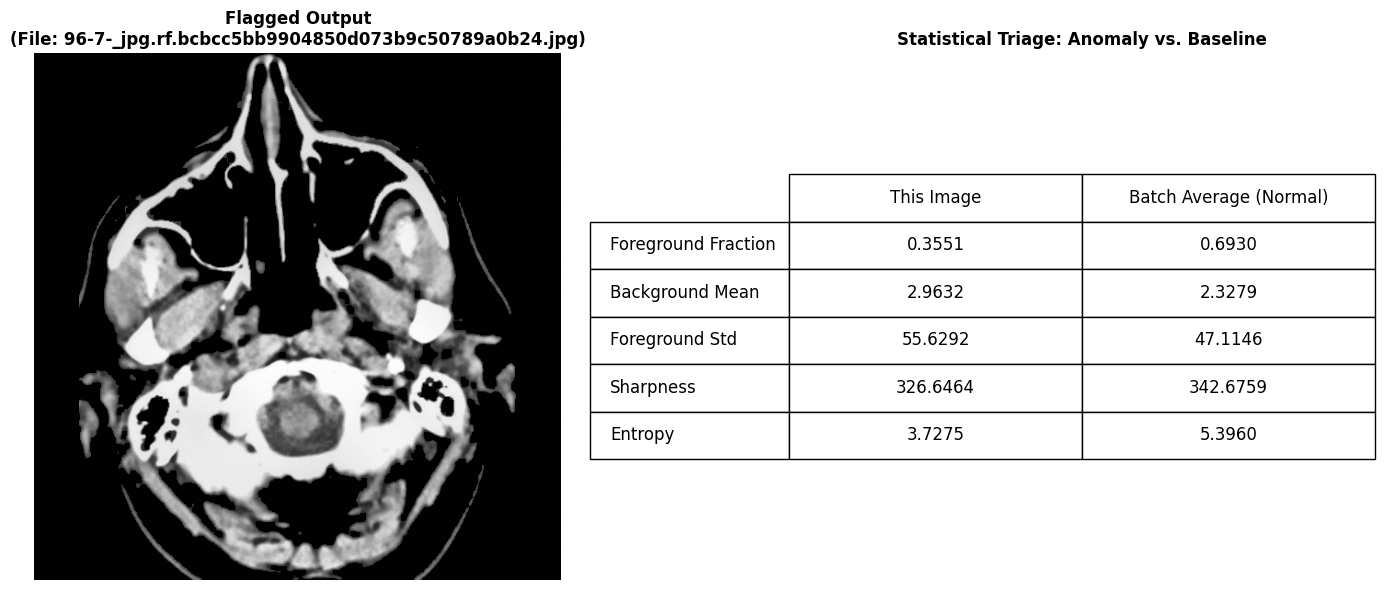

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import random

def extract_features_arch_a(image_path):
    """Architecture A: Dynamic Crop + Z-Score + CLAHE (With 5% Safety Gate)"""
    img = cv2.imread(image_path)
    if img is None: return None, None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_area = gray.shape[0] * gray.shape[1]

    # THE FIX: Replace Otsu with a hard threshold and morphological closing
    _, binary = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)

        # 5% Safety Gate
        if (w * h) > (original_area * 0.05):
            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            sq_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            sq_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            sq_gray, sq_mask = gray, mask
    else:
        sq_gray, sq_mask = gray, mask

    sq_float = sq_gray.astype(np.float32)
    pixels = sq_float[sq_mask > 0]

    if len(pixels) > 0:
        mean_v, std_v = np.mean(pixels), max(np.std(pixels), 10.0)
    else:
        mean_v, std_v = 100.0, 40.0

    norm = (sq_float - mean_v) / (std_v + 1e-7)
    squashed = np.tanh(norm / 3.1)
    std_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)
    std_uint8[sq_mask == 0] = 0

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    final_img = clahe.apply(std_uint8)

    return gray, final_img, sq_mask

def measure_extraction_quality(final_img, final_mask):
    """Calculates the 5 diagnostic metrics defined by Claude."""
    metrics = {}
    metrics['foreground_fraction'] = np.count_nonzero(final_mask) / final_mask.size

    bg_pixels = final_img[final_mask == 0]
    metrics['background_mean'] = float(np.mean(bg_pixels)) if bg_pixels.size > 0 else 0.0

    fg_pixels = final_img[final_mask > 0]
    metrics['foreground_std'] = float(np.std(fg_pixels)) if fg_pixels.size > 0 else 0.0

    metrics['sharpness'] = float(cv2.Laplacian(final_img, cv2.CV_64F).var())

    hist = cv2.calcHist([final_img], [0], None, [256], [0, 256]).flatten()
    hist_norm = hist / (hist.sum() + 1e-7)
    metrics['entropy'] = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))

    return metrics

dataset_paths = [
    '/content/dataset/train/Ischemic',
    '/content/dataset/Train/Ischemic',
    '/content/local_dataset/Train/Ischemic'
]
DATASET_PATH = next((p for p in dataset_paths if os.path.exists(p)), None)

if DATASET_PATH is None:
    print("⚠️ Dataset not found. Please check paths.")
else:
    print("📊 Running Batch Diagnostic on 100 images...\n")
    image_paths = glob.glob(os.path.join(DATASET_PATH, '*.*'))
    random.seed(42)
    sample_paths = random.sample(image_paths, min(100, len(image_paths)))

    results = []

    for path in sample_paths:
        raw_gray, final_img, final_mask = extract_features_arch_a(path)
        if final_img is not None:
            stats = measure_extraction_quality(final_img, final_mask)
            stats['file_path'] = path
            stats['raw_img'] = raw_gray
            stats['final_img'] = final_img
            results.append(stats)

    df = pd.DataFrame(results)

    # Calculate "Normal" Baseline (Mean across batch)
    batch_means = df.mean(numeric_only=True)

    # Let's find the image with the lowest foreground fraction (Likely Under-segmented)
    anomaly_idx = df['foreground_fraction'].idxmin()
    anomaly_row = df.loc[anomaly_idx]

    print("==========================================================")
    print(" 🚨 ANOMALY DETECTED: LOW FOREGROUND FRACTION")
    print("==========================================================")
    print("Diagnosis: Otsu likely under-segmented. Check if the mask missed part of the brain.")
    print(f"File: {os.path.basename(anomaly_row['file_path'])}")

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(anomaly_row['final_img'], cmap='gray')
    plt.title(f"Flagged Output\n(File: {os.path.basename(anomaly_row['file_path'])})", fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.axis('off')

    # Create a visual table comparing the anomaly to the batch mean
    cell_text = [
        [f"{anomaly_row['foreground_fraction']:.4f}", f"{batch_means['foreground_fraction']:.4f}"],
        [f"{anomaly_row['background_mean']:.4f}", f"{batch_means['background_mean']:.4f}"],
        [f"{anomaly_row['foreground_std']:.4f}", f"{batch_means['foreground_std']:.4f}"],
        [f"{anomaly_row['sharpness']:.4f}", f"{batch_means['sharpness']:.4f}"],
        [f"{anomaly_row['entropy']:.4f}", f"{batch_means['entropy']:.4f}"]
    ]
    rows = ['Foreground Fraction', 'Background Mean', 'Foreground Std', 'Sharpness', 'Entropy']
    cols = ['This Image', 'Batch Average (Normal)']

    table = plt.table(cellText=cell_text, rowLabels=rows, colLabels=cols, loc='center', cellLoc='center')
    table.scale(1, 2.5)
    table.set_fontsize(12)
    plt.title("Statistical Triage: Anomaly vs. Baseline", fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
!rm -rf /content/local_dataset/Preprocessed

In [ ]:
import os
import cv2
import numpy as np
import json
from glob import glob
from concurrent.futures import ThreadPoolExecutor

# =========================================================
# CONFIGURATION
# =========================================================
dataset_paths = [
    '/content/dataset/train',
    '/content/dataset/Train',
    '/content/local_dataset/train',
    '/content/local_dataset/Train',
    '/content/dataset'
]
RAW_DATASET_DIR = next((p for p in dataset_paths if os.path.exists(p)), '/content/local_dataset/Train')
PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'
AUDIT_LOG_FILE = os.path.join(PREPROCESSED_DIR, 'preprocessing_audit_log.json')
TARGET_SIZE = (224, 224)

# YOUR EMPIRICAL CALIBRATION CONSTANTS
FALLBACK_MEAN = 154.51
FALLBACK_STD = 71.42
SQUASH_FACTOR = 1.93

# =========================================================
# CORE PREPROCESSING LOGIC (THE SAFE, NON-DESTRUCTIVE METHOD)
# =========================================================
def process_safe_input(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("cv2.imread returned None (corrupted image)")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_h, original_w = gray.shape
    original_area = original_h * original_w

    # 1. Otsu Mask (No aggressive filling, just separating head from scanner space)
    _, raw_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing just to bridge tiny gaps, without deleting internal features
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(raw_thresh, cv2.MORPH_CLOSE, kernel)

    used_fallback = False

    # Safe Bounding Box: Grabs the box around ALL foreground pixels, so nothing is accidentally deleted
    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        bbox_area = w * h

        # 5% Sanity check against the ORIGINAL image size
        if bbox_area > (original_area * 0.05):
            # 2. Geometric Fix (Square Padding on the entire head)
            max_side = max(w, h)
            pad_top = max(0, (max_side - h) // 2)
            pad_bottom = max(0, max_side - h - pad_top)
            pad_left = max(0, (max_side - w) // 2)
            pad_right = max(0, max_side - w - pad_left)

            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = mask[y:y+h, x:x+w]

            square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
        else:
            square_gray, square_mask = gray, mask
            used_fallback = True
    else:
        square_gray, square_mask = gray, mask
        used_fallback = True
        bbox_area = 0

    # 3. Dynamic Z-Score & Tanh Compression
    square_float = square_gray.astype(np.float32)
    brain_pixels = square_float[square_mask > 0]

    if not used_fallback and brain_pixels.size > (square_float.size * 0.05):
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD
        used_fallback = True

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)

    # Map back to [0, 255]
    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # 4. CLAHE & Background Fix
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(standardized_uint8)
    clean_img = cv2.GaussianBlur(enhanced_gray, (3, 3), 0)

    # 🚨 THE FIX: Re-zero background AFTER CLAHE & Blur to guarantee absolute black!
    clean_img[square_mask == 0] = 0

    final_input = cv2.resize(clean_img, TARGET_SIZE)
    final_input_rgb = cv2.cvtColor(final_input, cv2.COLOR_GRAY2BGR)

    audit_data = {
        "mean_used": float(scan_mean),
        "std_used": float(scan_std),
        "bbox_area_pct": float(bbox_area / original_area) if original_area > 0 else 0.0,
        "used_fallback": used_fallback,
        "failed": False
    }

    return final_input_rgb, audit_data

# =========================================================
# BATCH EXECUTION
# =========================================================
def process_and_save(img_path):
    rel_path = os.path.relpath(img_path, RAW_DATASET_DIR)
    try:
        filename, _ = os.path.splitext(rel_path)
        save_path = os.path.join(PREPROCESSED_DIR, filename + '.png')
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        processed_img, audit_data = process_safe_input(img_path)

        if processed_img is not None:
            cv2.imwrite(save_path, processed_img)
            return (rel_path, audit_data)
        return (rel_path, {"failed": True, "reason": "None returned"})
    except Exception as e:
        return (rel_path, {"failed": True, "reason": str(e)})

if __name__ == "__main__":
    print("🚀 Starting SAFE Offline Dataset Preprocessing...")

    os.makedirs(PREPROCESSED_DIR, exist_ok=True)

    image_paths = glob(os.path.join(RAW_DATASET_DIR, '*/*.*'))

    if not image_paths:
        print(f"⚠️ ERROR: No images found in {RAW_DATASET_DIR}.")
    else:
        print(f"✅ Found {len(image_paths)} images. Processing safely...")
        audit_log = {}

        with ThreadPoolExecutor(max_workers=8) as executor:
            results = executor.map(process_and_save, image_paths)
            for res in results:
                if res is not None:
                    rel_path, audit_data = res
                    audit_log[rel_path] = audit_data

        with open(AUDIT_LOG_FILE, 'w') as f:
            json.dump(audit_log, f, indent=4)
        print(f"✅ Processing complete! Saved pristine dataset to {PREPROCESSED_DIR}")

🚀 Starting SAFE Offline Dataset Preprocessing...
✅ Found 17430 images. Processing safely...
✅ Processing complete! Saved pristine dataset to /content/local_dataset/Preprocessed


🔍 Searching for dataset directories...
✅ Found 17691 2D files and 5359 3D files.
🧠 Processing: 11205.dcm
🧠 Processing: 12037.png
🧠 Processing: 11033.png


/tmp/ipykernel_1084/505891143.py:221: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1084/505891143.py:221: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


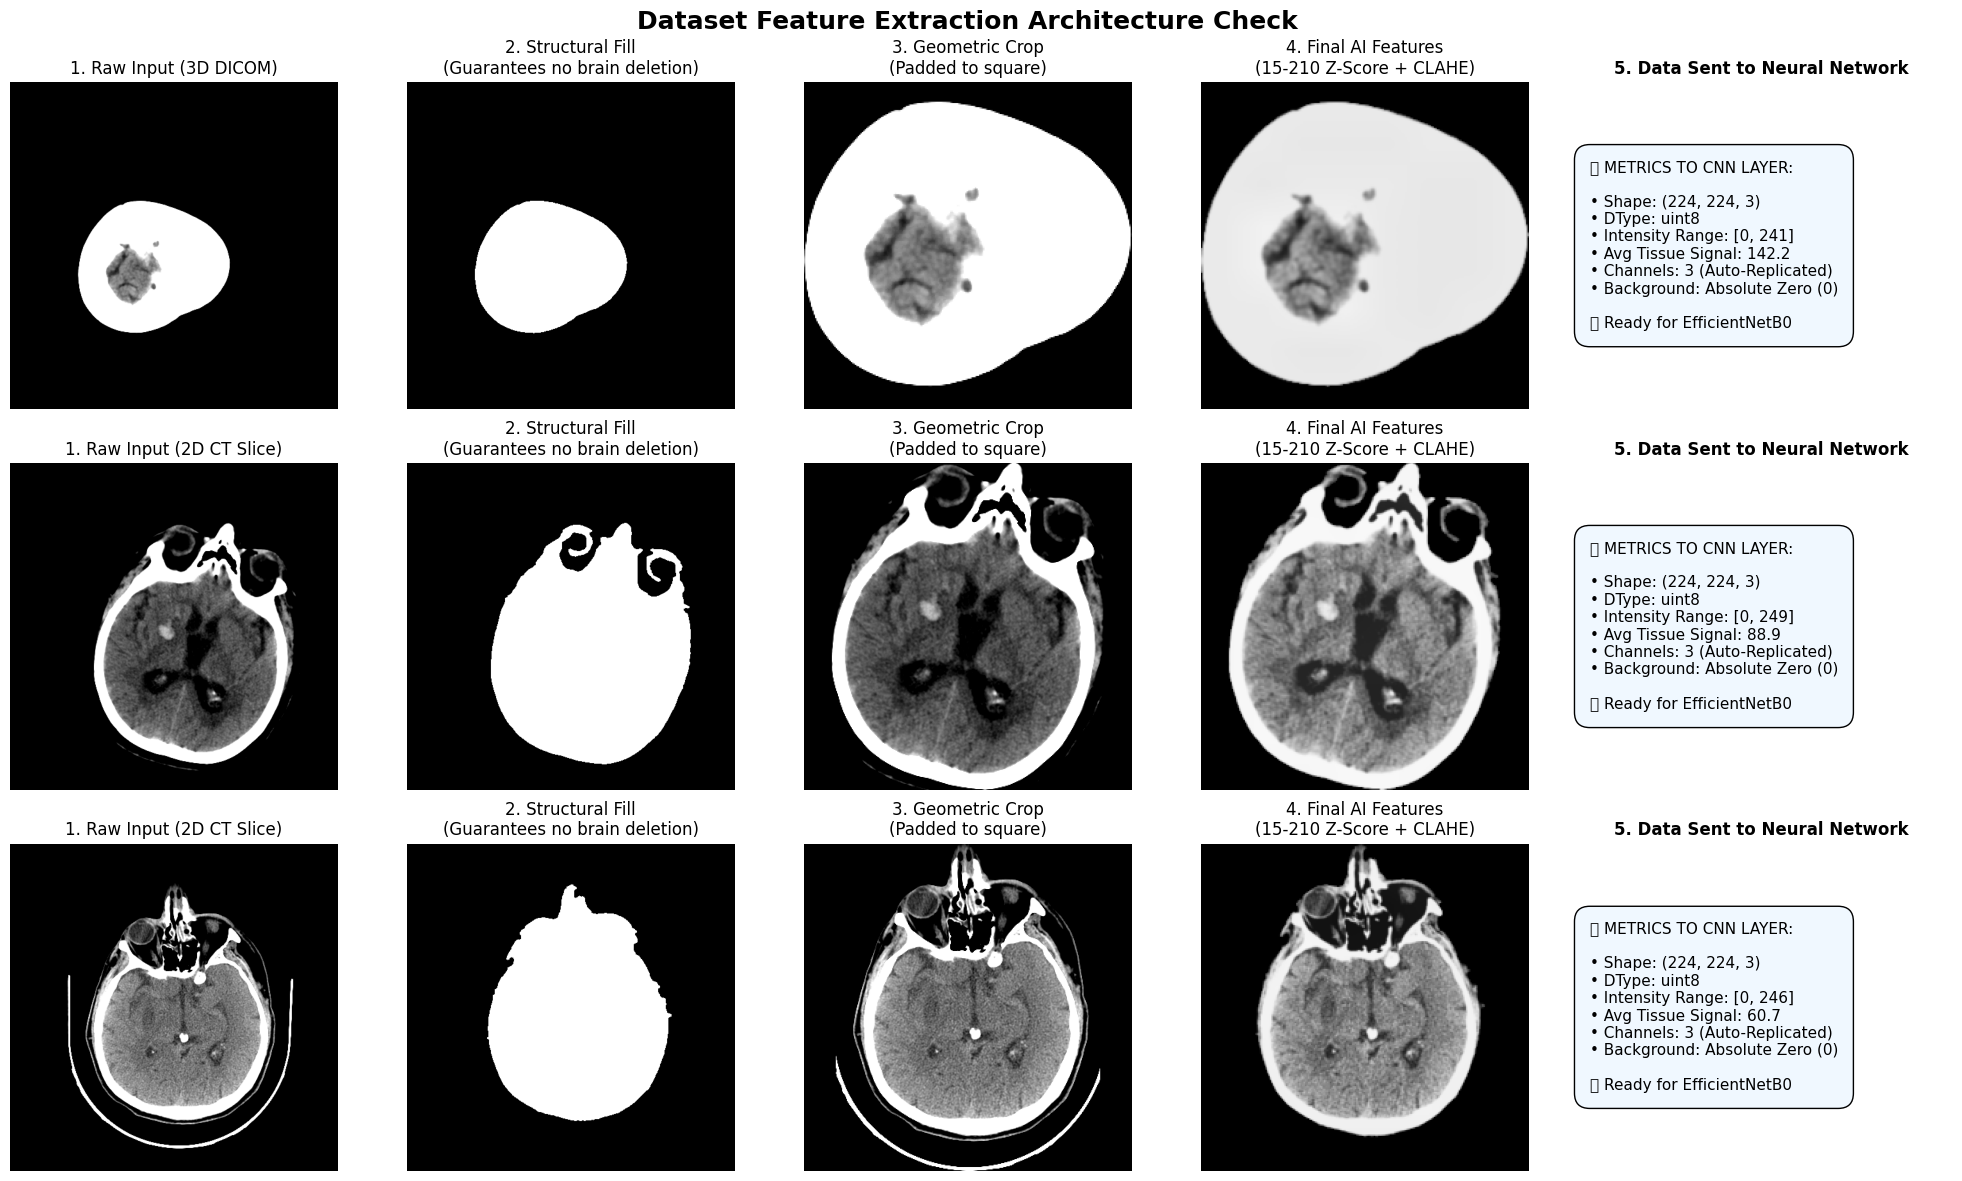

In [ ]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    import pydicom
    HAS_PYDICOM = True
except ImportError:
    HAS_PYDICOM = False
    print("ℹ️ pydicom not installed. If you have .dcm files, run '!pip install pydicom' first.")

# Your exact calibrated constants
FALLBACK_MEAN = 100.45
FALLBACK_STD = 45.35
SQUASH_FACTOR = 3.20
TARGET_SIZE = (224, 224)

def process_dicom_slice(dcm_path):
    """Safely converts a 3D raw DICOM slice to a standardized 8-bit array."""
    if not HAS_PYDICOM:
        raise ImportError("pydicom is required for 3D files.")

    dcm = pydicom.dcmread(dcm_path)
    pixel_array = dcm.pixel_array.astype(np.float32)

    # Hounsfield Unit (HU) Transformation
    intercept = dcm.get('RescaleIntercept', 0.0)
    slope = dcm.get('RescaleSlope', 1.0)
    hu_image = pixel_array * slope + intercept

    # Standard Brain Window (Window Center: 40, Window Width: 80)
    img_min = 40 - (80 // 2)
    img_max = 40 + (80 // 2)
    windowed = np.clip(hu_image, img_min, img_max)

    return ((windowed - img_min) / (img_max - img_min) * 255.0).astype(np.uint8)

def extract_features(image_path):
    """Executes the finalized Dual-Mask Architecture A on 2D or 3D files."""

    # 1. Input routing
    if image_path.lower().endswith('.dcm'):
        gray = process_dicom_slice(image_path)
        raw_display = gray.copy()
    else:
        img = cv2.imread(image_path)
        if img is None: return None, None, None, None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        raw_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    original_area = gray.shape[0] * gray.shape[1]

    # 2. STRUCTURAL MASK (Safe Contour Fill)
    _, raw_thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(raw_thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        if (w * h) > (original_area * 0.05):
            # The Fix: Solid fill to prevent internal tissue deletion
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            largest_contour = max(contours, key=cv2.contourArea)
            filled_mask = np.zeros_like(mask)
            cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = filled_mask[y:y+h, x:x+w]

            # Symmetrical Pad to Square
            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            sq_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            sq_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            sq_gray, sq_mask, filled_mask = gray, mask, mask
    else:
        sq_gray, sq_mask, filled_mask = gray, mask, mask

    # 3. STATISTICAL MASK & Z-SCORE (15 < gray < 210)
    sq_float = sq_gray.astype(np.float32)
    statistical_mask = (sq_gray > 15) & (sq_gray < 210) & (sq_mask > 0)
    brain_pixels = sq_float[statistical_mask]

    if brain_pixels.size > (sq_float.size * 0.05):
        scan_mean, scan_std = np.mean(brain_pixels), max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD

    normalized = (sq_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)
    std_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # 4. CLAHE & BACKGROUND FIX
    std_uint8[sq_mask == 0] = 0
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(std_uint8)
    clean_img = cv2.GaussianBlur(enhanced, (3, 3), 0)

    # Absolute zeroing of background to prevent leakage
    clean_img[sq_mask == 0] = 0

    # 5. PREPARE FINAL CNN TENSOR METRICS
    # Resize to the exact dimension the CNN expects and convert to 3-Channel RGB
    final_tensor = cv2.resize(clean_img, TARGET_SIZE)
    final_tensor = cv2.cvtColor(final_tensor, cv2.COLOR_GRAY2RGB)

    return raw_display, filled_mask, sq_gray, final_tensor

if __name__ == "__main__":
    print("🔍 Searching for dataset directories...")
    # Look for both raw dataset folders and test folders
    possible_paths = [
        '/content/dataset',
        '/content/local_dataset',
        '/content/dataset/train',
        os.getcwd()
    ]

    found_files_2d = []
    found_files_3d = []

    # Scan for 2D and 3D files inside the found directories
    for path in possible_paths:
        if os.path.exists(path):
            found_files_2d.extend(glob.glob(os.path.join(path, '**/*.png'), recursive=True))
            found_files_2d.extend(glob.glob(os.path.join(path, '**/*.jpg'), recursive=True))
            found_files_3d.extend(glob.glob(os.path.join(path, '**/*.dcm'), recursive=True))

    # Remove duplicates
    found_files_2d = list(set(found_files_2d))
    found_files_3d = list(set(found_files_3d))

    if not found_files_2d and not found_files_3d:
        print("❌ Error: Could not find any .png, .jpg, or .dcm files in your Colab workspace.")
        print("Please ensure your dataset is unzipped.")
    else:
        print(f"✅ Found {len(found_files_2d)} 2D files and {len(found_files_3d)} 3D files.")

        # Pick up to 3 random files to display (prioritize showing a 3D file if one exists)
        display_files = []
        random.seed(102) # Seeded for consistency

        if len(found_files_3d) > 0:
            display_files.append(random.choice(found_files_3d))

        # Fill the rest with 2D images
        while len(display_files) < 3 and len(found_files_2d) > 0:
            choice = random.choice(found_files_2d)
            if choice not in display_files:
                display_files.append(choice)

        # Widened figure to fit 5 columns instead of 4
        plt.figure(figsize=(20, 4 * len(display_files)))
        plt.suptitle("Dataset Feature Extraction Architecture Check", fontsize=18, fontweight='bold', y=0.98)

        for i, file_path in enumerate(display_files):
            print(f"🧠 Processing: {os.path.basename(file_path)}")
            raw, mask, cropped, final = extract_features(file_path)

            if raw is None: continue

            is_3d = file_path.lower().endswith('.dcm')
            file_type = "3D DICOM" if is_3d else "2D CT Slice"

            plt.subplot(len(display_files), 5, i*5 + 1)
            if len(raw.shape) == 3: plt.imshow(raw)
            else: plt.imshow(raw, cmap='gray')
            plt.title(f"1. Raw Input ({file_type})")
            plt.axis('off')

            plt.subplot(len(display_files), 5, i*5 + 2)
            plt.imshow(mask, cmap='gray')
            plt.title("2. Structural Fill\n(Guarantees no brain deletion)")
            plt.axis('off')

            plt.subplot(len(display_files), 5, i*5 + 3)
            plt.imshow(cropped, cmap='gray')
            plt.title("3. Geometric Crop\n(Padded to square)")
            plt.axis('off')

            plt.subplot(len(display_files), 5, i*5 + 4)
            plt.imshow(final) # Now it's 3-channel RGB, so no cmap='gray' needed
            plt.title("4. Final AI Features\n(15-210 Z-Score + CLAHE)")
            plt.axis('off')

            # THE NEW 5th COLUMN: Metrics Passed to the Model
            plt.subplot(len(display_files), 5, i*5 + 5)
            plt.axis('off')

            # Calculate what the CNN actually sees
            t_shape = final.shape
            t_min = final.min()
            t_max = final.max()
            t_mean = final.mean()

            stats_text = (
                f"🧠 METRICS TO CNN LAYER:\n\n"
                f"• Shape: {t_shape}\n"
                f"• DType: {final.dtype}\n"
                f"• Intensity Range: [{t_min}, {t_max}]\n"
                f"• Avg Tissue Signal: {t_mean:.1f}\n"
                f"• Channels: 3 (Auto-Replicated)\n"
                f"• Background: Absolute Zero (0)\n\n"
                f"✅ Ready for EfficientNetB0"
            )

            plt.text(0.05, 0.5, stats_text, fontsize=11, va='center',
                     bbox=dict(facecolor='#f0f8ff', edgecolor='black', boxstyle='round,pad=1'))
            plt.title("5. Data Sent to Neural Network", fontweight='bold')

        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

# dataset

In [ ]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
from concurrent.futures import ThreadPoolExecutor

PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'

def scan_processed_image(image_path):
    """Calculates Tier 1 metrics on an ALREADY PREPROCESSED image."""
    # Read in grayscale since the preprocessed images are saved as RGB/Grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # In our preprocessed images, the background is perfectly 0.
    # Therefore, foreground fraction is just pixels > 0.
    foreground_mask = (img > 0).astype(np.uint8)

    # 1. Foreground Fraction
    fg_fraction = np.count_nonzero(foreground_mask) / foreground_mask.size

    # 2. Entropy
    hist = cv2.calcHist([img], [0], foreground_mask, [256], [1, 256]).flatten() # Ignore 0
    hist_norm = hist / (hist.sum() + 1e-7)
    entropy = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))

    return {
        'file_path': image_path,
        'fg_fraction': fg_fraction,
        'entropy': entropy
    }

if __name__ == "__main__":
    print(f"🔍 Scanning full preprocessed dataset at: {PREPROCESSED_DIR}")

    # FIX: Add recursive=True and '**/*.*' to search inside subfolders!
    image_paths = glob.glob(os.path.join(PREPROCESSED_DIR, '**/*.*'), recursive=True)

    if not image_paths:
        print("⚠️ ERROR: No images found in Preprocessed directory.")
    else:
        print(f"⏳ Processing {len(image_paths)} images. Multithreading engaged...")
        results = []

        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in executor.map(scan_processed_image, image_paths):
                if res is not None:
                    results.append(res)

        df = pd.DataFrame(results)

        if df.empty:
            print("\n⚠️ ERROR: No valid images were successfully read.")
            print("This usually means the files are corrupted, or they are non-image hidden files (like .ipynb_checkpoints).")
        else:
            # Calculate Population Statistics
            mean_fg = df['fg_fraction'].mean()
            std_fg = df['fg_fraction'].std()

            mean_ent = df['entropy'].mean()
            std_ent = df['entropy'].std()

            # Flag anomalies (> 2 Standard Deviations from the mean)
            # Low foreground = possible tissue deletion. High/Low entropy = possible noise/over-masking.
            anomalies = df[
                (df['fg_fraction'] < (mean_fg - 2*std_fg)) |
                (df['fg_fraction'] > (mean_fg + 2*std_fg)) |
                (df['entropy'] < (mean_ent - 2*std_ent)) |
                (df['entropy'] > (mean_ent + 2*std_ent))
            ]

            print("\n=======================================================")
            print(f" 📊 FULL DATASET INTEGRITY REPORT (N={len(df)})")
            print("=======================================================")
            print(f"Average Foreground Fraction: {mean_fg:.4f} (± {std_fg:.4f})")
            print(f"Average Tissue Entropy:      {mean_ent:.4f} (± {std_ent:.4f})")
            print("-------------------------------------------------------")
            print(f"🚨 Statistical Outliers Flagged: {len(anomalies)} images ({(len(anomalies)/len(df))*100:.2f}%)")
            print("=======================================================")

            if len(anomalies) > 0:
                print("\n⚠️ SAMPLE OF FLAGGED OUTLIERS (Inspect these visually!):")
                # Sort by lowest foreground fraction to find the worst possible masking failures
                print(anomalies.sort_values(by='fg_fraction').head(10)[['file_path', 'fg_fraction', 'entropy']])

🔍 Scanning full preprocessed dataset at: /content/local_dataset/Preprocessed
⏳ Processing 17431 images. Multithreading engaged...

 📊 FULL DATASET INTEGRITY REPORT (N=17430)
Average Foreground Fraction: 0.4020 (± 0.1584)
Average Tissue Entropy:      6.9597 (± 0.7178)
-------------------------------------------------------
🚨 Statistical Outliers Flagged: 1406 images (8.07%)

⚠️ SAMPLE OF FLAGGED OUTLIERS (Inspect these visually!):
                                              file_path  fg_fraction   entropy
642   /content/local_dataset/Preprocessed/Hemorrhagi...     0.065549  6.892082
5585  /content/local_dataset/Preprocessed/Ischemic/1...     0.071070  6.558568
3599  /content/local_dataset/Preprocessed/Ischemic/1...     0.075514  6.116379
1934  /content/local_dataset/Preprocessed/Hemorrhagi...     0.076670  7.253732
4364  /content/local_dataset/Preprocessed/Ischemic/1...     0.078962  6.900502
8877  /content/local_dataset/Preprocessed/Normal/109...     0.083885  5.103186
6422  /conten

In [ ]:
!rm -rf /content/local_dataset/Preprocessed

In [ ]:
import os
import cv2
import numpy as np
import glob

def get_dual_mask_roi(gray_image):
    """Applies the Structural Mask for cropping and the Statistical Mask for math."""
    original_h, original_w = gray_image.shape
    original_area = original_h * original_w

    # 1. STRUCTURAL MASK (For Geometry and Cropping)
    # Hard threshold to isolate head from pitch black scanner air
    _, structural_thresh = cv2.threshold(gray_image, 15, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    structural_cleaned = cv2.morphologyEx(structural_thresh, cv2.MORPH_OPEN, kernel)
    structural_cleaned = cv2.morphologyEx(structural_cleaned, cv2.MORPH_CLOSE, kernel)

    coords = cv2.findNonZero(structural_cleaned)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        if (w * h) > (original_area * 0.05):
            contours, _ = cv2.findContours(structural_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            largest_contour = max(contours, key=cv2.contourArea)

            solid_structural_mask = np.zeros_like(gray_image)
            cv2.drawContours(solid_structural_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

            cropped_gray = gray_image[y:y+h, x:x+w]
            cropped_mask = solid_structural_mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pad_top = (max_side - h) // 2
            pad_bottom = max_side - h - pad_top
            pad_left = (max_side - w) // 2
            pad_right = max_side - w - pad_left

            square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            return square_gray, square_mask

    # Fallback if masking completely fails
    return gray_image, structural_cleaned

def run_empirical_calibration(train_dir, sample_size=500):
    print("🔬 Starting Empirical Calibration (Dual-Mask Strategy)...")

    all_images = glob.glob(os.path.join(train_dir, '**/*.*'), recursive=True)
    all_images = [p for p in all_images if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    np.random.shuffle(all_images)
    sample_images = all_images[:sample_size]

    print("\nStep 1: Calculating Global Brain Tissue Statistics (Excluding Skull)...")
    global_brain_pixels = []

    for img_path in sample_images:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        square_gray, square_mask = get_dual_mask_roi(img)

        # 2. STATISTICAL MASK (Exclude air < 15, exclude bone > 180)
        statistical_mask = (square_gray > 15) & (square_gray < 180) & (square_mask > 0)
        brain_pixels = square_gray.astype(np.float32)[statistical_mask]

        if len(brain_pixels) > (square_gray.size * 0.05):
            global_brain_pixels.extend(np.random.choice(brain_pixels, size=min(1000, len(brain_pixels)), replace=False))

    if not global_brain_pixels:
        print("⚠️ WARNING: Could not extract valid brain pixels.")
        global_brain_pixels = [100.0]

    fallback_mean = np.mean(global_brain_pixels)
    fallback_std = max(np.std(global_brain_pixels), 10.0)

    print("Step 2: Calculating Hemorrhage Z-Score Extremes (Squash Factor)...")
    bleeding_images = [p for p in all_images if 'Bleeding' in p or 'Hemorrhagic' in p or 'bleed' in p.lower()]

    if not bleeding_images:
        bleeding_images = all_images

    np.random.shuffle(bleeding_images)
    bleed_samples = bleeding_images[:min(sample_size, len(bleeding_images))]

    pathological_z_scores = []
    for img_path in bleed_samples:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        square_gray, square_mask = get_dual_mask_roi(img)

        # Calculate dynamic mean/std for this specific scan (excluding bone)
        statistical_mask = (square_gray > 15) & (square_gray < 180) & (square_mask > 0)
        brain_pixels = square_gray.astype(np.float32)[statistical_mask]

        if len(brain_pixels) < (square_gray.size * 0.05): continue

        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)

        # Look at the brightest soft-tissue anomalies (bleeds)
        intensity_threshold = np.percentile(brain_pixels, 95)
        hemorrhage_pixels = brain_pixels[brain_pixels >= intensity_threshold]

        z_scores = (hemorrhage_pixels - scan_mean) / scan_std
        pathological_z_scores.extend(z_scores)

    squash_factor = np.percentile(pathological_z_scores, 90) if pathological_z_scores else 3.1

    print("\n" + "="*50)
    print("🚀 NEW PIPELINE CALIBRATION CONSTANTS:")
    print("="*50)
    print(f"FALLBACK_MEAN   = {fallback_mean:.2f}")
    print(f"FALLBACK_STD    = {fallback_std:.2f}")
    print(f"SQUASH_FACTOR   = {max(squash_factor, 1.0):.2f}")
    print("="*50)
    print("⚠️ UPDATE THESE NUMBERS IN THE BATCH PREPROCESSOR SCRIPT!")

dataset_paths = ['/content/dataset/train', '/content/dataset/Train', '/content/local_dataset/train']
TRAIN_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)

if TRAIN_DIR:
    run_empirical_calibration(TRAIN_DIR)
else:
    print("⚠️ Could not find raw training directory.")

🔬 Starting Empirical Calibration (Dual-Mask Strategy)...

Step 1: Calculating Global Brain Tissue Statistics (Excluding Skull)...
Step 2: Calculating Hemorrhage Z-Score Extremes (Squash Factor)...

🚀 NEW PIPELINE CALIBRATION CONSTANTS:
FALLBACK_MEAN   = 96.10
FALLBACK_STD    = 42.06
SQUASH_FACTOR   = 3.01
⚠️ UPDATE THESE NUMBERS IN THE BATCH PREPROCESSOR SCRIPT!


In [ ]:
import cv2
import numpy as np
import os
import glob
import json
from concurrent.futures import ThreadPoolExecutor

# ========================================================
# ⚠️ UPDATE THESE WITH THE NUMBERS FROM SCRIPT 1
# ========================================================
FALLBACK_MEAN = 154.51 # Placeholder: Update me!
FALLBACK_STD = 71.42   # Placeholder: Update me!
SQUASH_FACTOR = 1.93   # Placeholder: Update me!
TARGET_SIZE = (224, 224)

def process_perfect_input(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("cv2.imread returned None (corrupted image)")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_h, original_w = gray.shape
    original_area = original_h * original_w

    # 1. STRUCTURAL MASK (For Geometry and Cropping)
    # Pitch black air is < 15. The head is > 15.
    _, structural_thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    structural_cleaned = cv2.morphologyEx(structural_thresh, cv2.MORPH_OPEN, kernel)
    structural_cleaned = cv2.morphologyEx(structural_cleaned, cv2.MORPH_CLOSE, kernel)

    used_fallback = False

    coords = cv2.findNonZero(structural_cleaned)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        bbox_area = w * h

        # 5% Safety Gate
        if bbox_area > (original_area * 0.05):

            # THE FIX: We find the external contour and fill it solidly.
            # This guarantees we never accidentally delete a sinus or a piece of brain tissue.
            contours, _ = cv2.findContours(structural_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            largest_contour = max(contours, key=cv2.contourArea)

            solid_structural_mask = np.zeros_like(gray)
            cv2.drawContours(solid_structural_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

            # Crop to bounding box using the SOLID mask
            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = solid_structural_mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pad_top = (max_side - h) // 2
            pad_bottom = max_side - h - pad_top
            pad_left = (max_side - w) // 2
            pad_right = max_side - w - pad_left

            square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)

        else:
            square_gray, square_mask = gray, structural_cleaned
            used_fallback = True
    else:
        square_gray, square_mask = gray, structural_cleaned
        used_fallback = True

    # 2. STATISTICAL MASK (For Z-Score Math Only)
    # We explicitly exclude bright white bone (>180) so it doesn't skew our brain tissue math.
    square_float = square_gray.astype(np.float32)
    statistical_mask = (square_gray > 15) & (square_gray < 180) & (square_mask > 0)

    brain_pixels = square_float[statistical_mask]

    if not used_fallback and brain_pixels.size > (square_float.size * 0.05):
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD
        used_fallback = True

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)
    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # Zero the background using the SOLID structural mask
    standardized_uint8[square_mask == 0] = 0

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(standardized_uint8)
    clean_img = cv2.GaussianBlur(enhanced_gray, (3, 3), 0)

    # Claude's Fix: Re-apply the mask AFTER CLAHE to ensure absolute 0.00 background
    clean_img[square_mask == 0] = 0

    final_input = cv2.resize(clean_img, TARGET_SIZE)

    return final_input, used_fallback

if __name__ == "__main__":
    dataset_paths = ['/content/dataset/train', '/content/dataset/Train', '/content/local_dataset/train']
    RAW_DATASET_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)
    PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'
    AUDIT_LOG_FILE = os.path.join(PREPROCESSED_DIR, 'preprocessing_audit_log.json')

    if RAW_DATASET_DIR is None:
        print("⚠️ CRITICAL: Could not find raw dataset folder. Check paths.")
    else:
        image_paths = glob.glob(os.path.join(RAW_DATASET_DIR, '**/*.*'), recursive=True)
        valid_images = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not valid_images:
            print(f"⚠️ No images found in {RAW_DATASET_DIR}.")
        else:
            print(f"🚀 Starting SAFE Offline Dataset Preprocessing (Dual-Mask Strategy)...")
            print(f"✅ Found {len(valid_images)} images. Processing safely...")

            os.makedirs(PREPROCESSED_DIR, exist_ok=True)
            audit_log = {}

            def process_and_save(img_path):
                rel_path = os.path.relpath(img_path, RAW_DATASET_DIR)
                out_path = os.path.join(PREPROCESSED_DIR, rel_path)
                out_dir = os.path.dirname(out_path)

                os.makedirs(out_dir, exist_ok=True)

                try:
                    final_tensor, fb = process_perfect_input(img_path)
                    if final_tensor is not None:
                        cv2.imwrite(out_path, final_tensor)
                        return rel_path, {"status": "SUCCESS", "used_fallback": fb}
                except Exception as e:
                    return rel_path, {"status": "FAILED", "error": str(e)}
                return rel_path, {"status": "FAILED", "error": "Unknown"}

            with ThreadPoolExecutor(max_workers=8) as executor:
                for rel_path, audit_data in executor.map(process_and_save, valid_images):
                    if audit_data:
                        audit_log[rel_path] = audit_data

            with open(AUDIT_LOG_FILE, 'w') as f:
                json.dump(audit_log, f, indent=4)

            print(f"✅ Processing complete! Saved pristine dataset to {PREPROCESSED_DIR}")

🚀 Starting SAFE Offline Dataset Preprocessing (Dual-Mask Strategy)...
✅ Found 17430 images. Processing safely...
✅ Processing complete! Saved pristine dataset to /content/local_dataset/Preprocessed


In [ ]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
from concurrent.futures import ThreadPoolExecutor

PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'

def scan_processed_image(image_path):
    """Calculates Tier 1 metrics on an ALREADY PREPROCESSED image."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    foreground_mask = (img > 0).astype(np.uint8)

    # 1. Foreground Fraction
    fg_fraction = np.count_nonzero(foreground_mask) / foreground_mask.size

    # 2. Entropy
    hist = cv2.calcHist([img], [0], foreground_mask, [256], [1, 256]).flatten() # Ignore 0
    hist_norm = hist / (hist.sum() + 1e-7)
    entropy = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))

    return {
        'file_path': image_path,
        'fg_fraction': fg_fraction,
        'entropy': entropy
    }

if __name__ == "__main__":
    print(f"🔍 Scanning full preprocessed dataset at: {PREPROCESSED_DIR}")

    # We use recursive=True to check every subfolder safely
    image_paths = glob.glob(os.path.join(PREPROCESSED_DIR, '**/*.*'), recursive=True)
    valid_images = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not valid_images:
        print("⚠️ ERROR: No images found in Preprocessed directory.")
    else:
        print(f"⏳ Processing {len(valid_images)} images. Multithreading engaged...")
        results = []

        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in executor.map(scan_processed_image, valid_images):
                if res is not None:
                    results.append(res)

        df = pd.DataFrame(results)

        if df.empty:
            print("\n⚠️ ERROR: No valid images were successfully read.")
        else:
            mean_fg = df['fg_fraction'].mean()
            std_fg = df['fg_fraction'].std()

            mean_ent = df['entropy'].mean()
            std_ent = df['entropy'].std()

            anomalies = df[
                (df['fg_fraction'] < (mean_fg - 2*std_fg)) |
                (df['fg_fraction'] > (mean_fg + 2*std_fg)) |
                (df['entropy'] < (mean_ent - 2*std_ent)) |
                (df['entropy'] > (mean_ent + 2*std_ent))
            ]

            print("\n=======================================================")
            print(f" 📊 FULL DATASET INTEGRITY REPORT (N={len(df)})")
            print("=======================================================")
            print(f"Average Foreground Fraction: {mean_fg:.4f} (± {std_fg:.4f})")
            print(f"Average Tissue Entropy:      {mean_ent:.4f} (± {std_ent:.4f})")
            print("-------------------------------------------------------")
            print(f"🚨 Statistical Outliers Flagged: {len(anomalies)} images ({(len(anomalies)/len(df))*100:.2f}%)")
            print("=======================================================")

            if len(anomalies) > 0:
                print("\n⚠️ SAMPLE OF FLAGGED OUTLIERS (Inspect these visually!):")
                print(anomalies.sort_values(by='fg_fraction').head(10)[['file_path', 'fg_fraction', 'entropy']])

🔍 Scanning full preprocessed dataset at: /content/local_dataset/Preprocessed
⏳ Processing 17430 images. Multithreading engaged...

 📊 FULL DATASET INTEGRITY REPORT (N=17430)
Average Foreground Fraction: 0.5965 (± 0.2249)
Average Tissue Entropy:      6.7917 (± 0.9071)
-------------------------------------------------------
🚨 Statistical Outliers Flagged: 954 images (5.47%)

⚠️ SAMPLE OF FLAGGED OUTLIERS (Inspect these visually!):
                                               file_path  fg_fraction  \
15188  /content/local_dataset/Preprocessed/Normal/122...     0.121811   
11670  /content/local_dataset/Preprocessed/Normal/158...     0.128966   
333    /content/local_dataset/Preprocessed/Hemorrhagi...     0.131338   
11543  /content/local_dataset/Preprocessed/Normal/158...     0.132753   
1470   /content/local_dataset/Preprocessed/Hemorrhagi...     0.133032   
5438   /content/local_dataset/Preprocessed/Ischemic/1...     0.135662   
1898   /content/local_dataset/Preprocessed/Hemorrhagi...

🔬 Analyzing Hemorrhage pixel intensities in: /content/dataset/train/Hemorrhagic


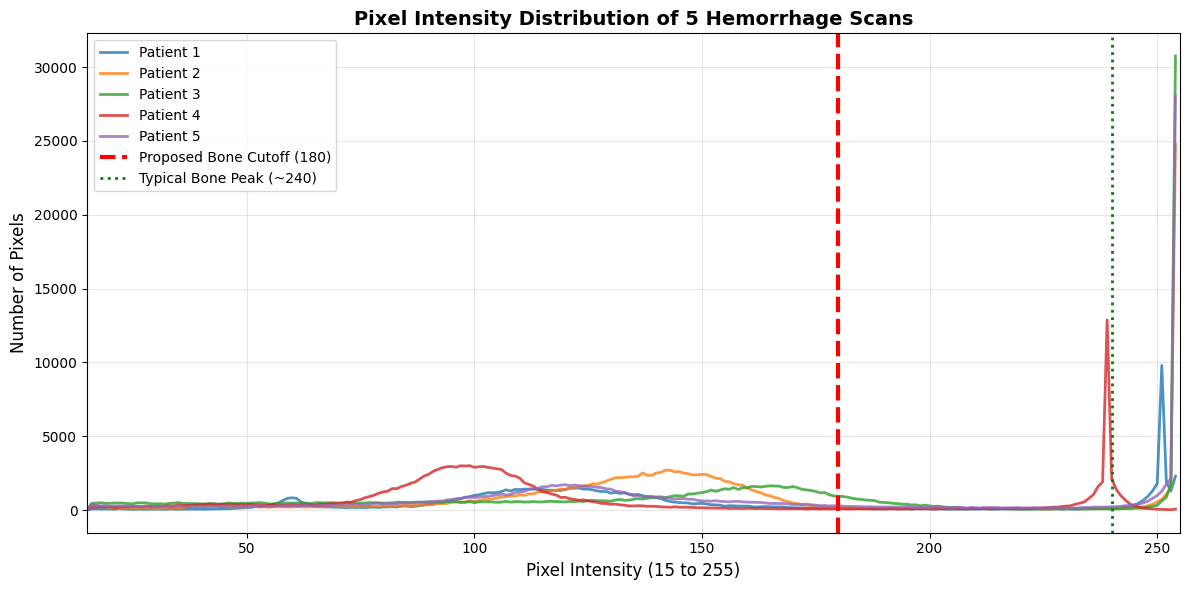

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random

dataset_paths = [
    '/content/dataset/train/Hemorrhagic',
    '/content/dataset/train/Bleeding',
    '/content/dataset/Train/Hemorrhagic',
    '/content/dataset/Train/Bleeding',
    '/content/local_dataset/train/Hemorrhagic'
]
DATASET_PATH = next((p for p in dataset_paths if os.path.exists(p)), None)

if DATASET_PATH is None:
    print("⚠️ Could not find the Hemorrhagic/Bleeding folder. Check your Colab paths.")
else:
    print(f"🔬 Analyzing Hemorrhage pixel intensities in: {DATASET_PATH}")
    image_paths = glob.glob(os.path.join(DATASET_PATH, '*.*'))
    random.seed(105) # Seeded to grab a few distinct cases
    sample_paths = random.sample(image_paths, min(5, len(image_paths)))

    plt.figure(figsize=(12, 6))

    for i, path in enumerate(sample_paths):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        # We only care about the head, so we ignore the pitch-black air (< 15)
        head_pixels = img[img > 15]

        # Calculate the histogram of the tissue and bone
        hist, bins = np.histogram(head_pixels, bins=240, range=(15, 255))

        # Plot the curve for this specific patient
        plt.plot(bins[:-1], hist, alpha=0.8, linewidth=2, label=f'Patient {i+1}')

    # Draw our proposed 180 cutoff line
    plt.axvline(x=180, color='red', linestyle='--', linewidth=3, label='Proposed Bone Cutoff (180)')

    # Draw a line where bone usually peaks
    plt.axvline(x=240, color='green', linestyle=':', linewidth=2, label='Typical Bone Peak (~240)')

    plt.title("Pixel Intensity Distribution of 5 Hemorrhage Scans", fontsize=14, fontweight='bold')
    plt.xlabel("Pixel Intensity (15 to 255)", fontsize=12)
    plt.ylabel("Number of Pixels", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(15, 255)

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import cv2
import numpy as np
import glob

def get_dual_mask_roi(gray_image):
    """Applies the Structural Mask for cropping and geometry."""
    # 1. STRUCTURAL MASK: Hard threshold for head vs air
    _, raw_thresh = cv2.threshold(gray_image, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(raw_thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        # THE SAFEGUARD: Fill the contour to prevent internal sinus/tissue deletion
        filled_mask = np.zeros_like(gray_image)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

        x, y, w, h = cv2.boundingRect(largest_contour)
        if (w * h) > (gray_image.size * 0.05):
            cropped_gray = gray_image[y:y+h, x:x+w]
            cropped_mask = filled_mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pad_top = (max_side - h) // 2
            pad_bottom = max_side - h - pad_top
            pad_left = (max_side - w) // 2
            pad_right = max_side - w - pad_left

            square_gray = cv2.copyMakeBorder(cropped_gray, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
            return square_gray, square_mask

    # Fallback pads to square so it doesn't break CNN dimensions
    h, w = gray_image.shape
    ms = max(w, h)
    pt = (ms - h) // 2
    pb = ms - h - pt
    pl = (ms - w) // 2
    pr = ms - w - pl
    sq_g = cv2.copyMakeBorder(gray_image, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
    sq_m = cv2.copyMakeBorder(mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
    return sq_g, sq_m

def run_empirical_calibration(train_dir, sample_size=500):
    print("🔬 Starting Empirical Calibration (Dual-Mask Strategy)...")

    all_images = glob.glob(os.path.join(train_dir, '**/*.*'), recursive=True)
    all_images = [p for p in all_images if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    np.random.shuffle(all_images)
    sample_images = all_images[:sample_size]

    print("\nStep 1: Calculating Global Brain Tissue Statistics...")
    global_brain_pixels = []

    for img_path in sample_images:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        square_gray, square_mask = get_dual_mask_roi(img)

        # 2. STATISTICAL MASK (Exclude air < 15, exclude bone > 210)
        statistical_mask = (square_gray > 15) & (square_gray < 210) & (square_mask > 0)
        brain_pixels = square_gray.astype(np.float32)[statistical_mask]

        if len(brain_pixels) > (square_gray.size * 0.05):
            global_brain_pixels.extend(np.random.choice(brain_pixels, size=min(1000, len(brain_pixels)), replace=False))

    fallback_mean = np.mean(global_brain_pixels)
    fallback_std = max(np.std(global_brain_pixels), 10.0)

    print("Step 2: Calculating Hemorrhage Z-Score Extremes (Squash Factor)...")
    bleeding_images = [p for p in all_images if 'Bleeding' in p or 'Hemorrhagic' in p or 'bleed' in p.lower()]
    if not bleeding_images: bleeding_images = all_images

    np.random.shuffle(bleeding_images)
    bleed_samples = bleeding_images[:min(sample_size, len(bleeding_images))]

    pathological_z_scores = []
    for img_path in bleed_samples:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        square_gray, square_mask = get_dual_mask_roi(img)

        statistical_mask = (square_gray > 15) & (square_gray < 210) & (square_mask > 0)
        brain_pixels = square_gray.astype(np.float32)[statistical_mask]

        if len(brain_pixels) < (square_gray.size * 0.05): continue

        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)

        intensity_threshold = np.percentile(brain_pixels, 95)
        hemorrhage_pixels = brain_pixels[brain_pixels >= intensity_threshold]

        z_scores = (hemorrhage_pixels - scan_mean) / scan_std
        pathological_z_scores.extend(z_scores)

    squash_factor = np.percentile(pathological_z_scores, 90) if pathological_z_scores else 3.1

    print("\n" + "="*50)
    print("🚀 FINAL CALIBRATION CONSTANTS (Paste these into Script 2):")
    print("="*50)
    print(f"FALLBACK_MEAN   = {fallback_mean:.2f}")
    print(f"FALLBACK_STD    = {fallback_std:.2f}")
    print(f"SQUASH_FACTOR   = {max(squash_factor, 1.0):.2f}")
    print("="*50)

dataset_paths = ['/content/dataset/train', '/content/dataset/Train', '/content/local_dataset/train']
TRAIN_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)
if TRAIN_DIR: run_empirical_calibration(TRAIN_DIR)

🔬 Starting Empirical Calibration (Dual-Mask Strategy)...

Step 1: Calculating Global Brain Tissue Statistics...
Step 2: Calculating Hemorrhage Z-Score Extremes (Squash Factor)...

🚀 FINAL CALIBRATION CONSTANTS (Paste these into Script 2):
FALLBACK_MEAN   = 100.45
FALLBACK_STD    = 45.35
SQUASH_FACTOR   = 3.20


In [ ]:
import cv2
import numpy as np
import os
import glob
from concurrent.futures import ThreadPoolExecutor

# ========================================================
# ⚠️ UPDATE THESE WITH THE OUTPUT FROM SCRIPT 1
# ========================================================
FALLBACK_MEAN = 154.51 # Update me after running Script 1!
FALLBACK_STD = 71.42   # Update me after running Script 1!
SQUASH_FACTOR = 1.93   # Update me after running Script 1!
TARGET_SIZE = (224, 224)

def process_perfect_input(image_path):
    img = cv2.imread(image_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. STRUCTURAL MASK (For Geometry and Cropping)
    _, raw_thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(raw_thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        filled_mask = np.zeros_like(gray)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

        x, y, w, h = cv2.boundingRect(largest_contour)
        if (w * h) > (gray.size * 0.05):
            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = filled_mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            square_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            square_gray, square_mask = gray, mask
    else:
        h, w = gray.shape
        ms = max(w, h)
        pt = (ms - h) // 2
        pb = ms - h - pt
        pl = (ms - w) // 2
        pr = ms - w - pl
        square_gray = cv2.copyMakeBorder(gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        square_mask = cv2.copyMakeBorder(mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)

    # 2. STATISTICAL MASK (For Z-Score Math Only)
    square_float = square_gray.astype(np.float32)
    statistical_mask = (square_gray > 15) & (square_gray < 210) & (square_mask > 0)

    brain_pixels = square_float[statistical_mask]

    if brain_pixels.size > (square_float.size * 0.05):
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)
    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # 3. CLAHE & FINAL BACKGROUND ZEROING
    standardized_uint8[square_mask == 0] = 0
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(standardized_uint8)
    clean_img = cv2.GaussianBlur(enhanced_gray, (3, 3), 0)

    # Absolute guarantee against background leakage
    clean_img[square_mask == 0] = 0

    final_input = cv2.resize(clean_img, TARGET_SIZE)
    # Claude's Fix: Explicit 3-Channel conversion for robust CNN loading
    final_input_bgr = cv2.cvtColor(final_input, cv2.COLOR_GRAY2BGR)

    return final_input_bgr

if __name__ == "__main__":
    dataset_paths = ['/content/dataset/train', '/content/dataset/Train', '/content/local_dataset/train']
    RAW_DATASET_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)
    PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'

    if RAW_DATASET_DIR:
        image_paths = glob.glob(os.path.join(RAW_DATASET_DIR, '**/*.*'), recursive=True)
        valid_images = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"🚀 Starting SAFE Offline Dataset Preprocessing (Dual-Mask)...")
        os.makedirs(PREPROCESSED_DIR, exist_ok=True)

        def process_and_save(img_path):
            rel_path = os.path.relpath(img_path, RAW_DATASET_DIR)
            out_path = os.path.join(PREPROCESSED_DIR, rel_path)
            os.makedirs(os.path.dirname(out_path), exist_ok=True)
            try:
                final_tensor = process_perfect_input(img_path)
                if final_tensor is not None: cv2.imwrite(out_path, final_tensor)
            except Exception as e: pass

        with ThreadPoolExecutor(max_workers=8) as executor:
            list(executor.map(process_and_save, valid_images))

        print(f"✅ Processing complete! Saved pristine dataset to {PREPROCESSED_DIR}")

🚀 Starting SAFE Offline Dataset Preprocessing (Dual-Mask)...
✅ Processing complete! Saved pristine dataset to /content/local_dataset/Preprocessed


In [ ]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
from concurrent.futures import ThreadPoolExecutor

PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'

def scan_processed_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None

    foreground_mask = (img > 0).astype(np.uint8)
    fg_fraction = np.count_nonzero(foreground_mask) / foreground_mask.size

    hist = cv2.calcHist([img], [0], foreground_mask, [256], [1, 256]).flatten()
    hist_norm = hist / (hist.sum() + 1e-7)
    entropy = float(-np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0])))

    return {'file_path': image_path, 'fg_fraction': fg_fraction, 'entropy': entropy}

if __name__ == "__main__":
    print(f"🔍 Scanning full preprocessed dataset at: {PREPROCESSED_DIR}")
    image_paths = glob.glob(os.path.join(PREPROCESSED_DIR, '**/*.*'), recursive=True)
    valid_images = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if valid_images:
        print(f"⏳ Processing {len(valid_images)} images. Multithreading engaged...")
        results = []
        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in executor.map(scan_processed_image, valid_images):
                if res is not None: results.append(res)

        df = pd.DataFrame(results)

        if not df.empty:
            mean_fg, std_fg = df['fg_fraction'].mean(), df['fg_fraction'].std()
            mean_ent, std_ent = df['entropy'].mean(), df['entropy'].std()

            anomalies = df[
                (df['fg_fraction'] < (mean_fg - 2*std_fg)) |
                (df['fg_fraction'] > (mean_fg + 2*std_fg)) |
                (df['entropy'] < (mean_ent - 2*std_ent))
            ]

            print("\n=======================================================")
            print(f" 📊 FULL DATASET INTEGRITY REPORT (N={len(df)})")
            print("=======================================================")
            print(f"Average Foreground Fraction: {mean_fg:.4f} (± {std_fg:.4f})")
            print(f"Average Tissue Entropy:      {mean_ent:.4f} (± {std_ent:.4f})")
            print("-------------------------------------------------------")
            print(f"🚨 Statistical Outliers Flagged: {len(anomalies)} images ({(len(anomalies)/len(df))*100:.2f}%)")
            print("=======================================================")

🔍 Scanning full preprocessed dataset at: /content/local_dataset/Preprocessed
⏳ Processing 17430 images. Multithreading engaged...

 📊 FULL DATASET INTEGRITY REPORT (N=17430)
Average Foreground Fraction: 0.7221 (± 0.1469)
Average Tissue Entropy:      6.8104 (± 0.8943)
-------------------------------------------------------
🚨 Statistical Outliers Flagged: 968 images (5.55%)


In [ ]:
!rm -rf /content/local_dataset/Preprocessed

In [ ]:
import cv2
import numpy as np
import os
import glob
from concurrent.futures import ThreadPoolExecutor

# ========================================================
# ⚠️ UPDATE THESE WITH THE OUTPUT FROM SCRIPT 1
# ========================================================
FALLBACK_MEAN = 100.45 # Update me after running Script 1!
FALLBACK_STD = 45.35   # Update me after running Script 1!
SQUASH_FACTOR = 3.20   # Update me after running Script 1!
TARGET_SIZE = (224, 224)

def process_perfect_input(image_path):
    img = cv2.imread(image_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. STRUCTURAL MASK (For Geometry and Cropping)
    _, raw_thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(raw_thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        filled_mask = np.zeros_like(gray)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

        x, y, w, h = cv2.boundingRect(largest_contour)
        if (w * h) > (gray.size * 0.05):
            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = filled_mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            square_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            square_gray, square_mask = gray, mask
    else:
        h, w = gray.shape
        ms = max(w, h)
        pt = (ms - h) // 2
        pb = ms - h - pt
        pl = (ms - w) // 2
        pr = ms - w - pl
        square_gray = cv2.copyMakeBorder(gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        square_mask = cv2.copyMakeBorder(mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)

    # 2. STATISTICAL MASK (For Z-Score Math Only)
    square_float = square_gray.astype(np.float32)
    statistical_mask = (square_gray > 15) & (square_gray < 210) & (square_mask > 0)

    brain_pixels = square_float[statistical_mask]

    if brain_pixels.size > (square_float.size * 0.05):
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)
    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # 3. CLAHE & FINAL BACKGROUND ZEROING
    standardized_uint8[square_mask == 0] = 0
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(standardized_uint8)
    clean_img = cv2.GaussianBlur(enhanced_gray, (3, 3), 0)

    # Absolute guarantee against background leakage
    clean_img[square_mask == 0] = 0

    final_input = cv2.resize(clean_img, TARGET_SIZE)
    # Claude's Fix: Explicit 3-Channel conversion for robust CNN loading
    final_input_bgr = cv2.cvtColor(final_input, cv2.COLOR_GRAY2BGR)

    return final_input_bgr

if __name__ == "__main__":
    dataset_paths = ['/content/dataset/train', '/content/dataset/Train', '/content/local_dataset/train']
    RAW_DATASET_DIR = next((p for p in dataset_paths if os.path.exists(p)), None)
    PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'

    if RAW_DATASET_DIR:
        image_paths = glob.glob(os.path.join(RAW_DATASET_DIR, '**/*.*'), recursive=True)
        valid_images = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"🚀 Starting SAFE Offline Dataset Preprocessing (Dual-Mask)...")
        os.makedirs(PREPROCESSED_DIR, exist_ok=True)

        def process_and_save(img_path):
            rel_path = os.path.relpath(img_path, RAW_DATASET_DIR)
            out_path = os.path.join(PREPROCESSED_DIR, rel_path)
            os.makedirs(os.path.dirname(out_path), exist_ok=True)
            try:
                final_tensor = process_perfect_input(img_path)
                if final_tensor is not None: cv2.imwrite(out_path, final_tensor)
            except Exception as e: pass

        with ThreadPoolExecutor(max_workers=8) as executor:
            list(executor.map(process_and_save, valid_images))

        print(f"✅ Processing complete! Saved pristine dataset to {PREPROCESSED_DIR}")

🚀 Starting SAFE Offline Dataset Preprocessing (Dual-Mask)...
✅ Processing complete! Saved pristine dataset to /content/local_dataset/Preprocessed


#EfficientNetB0

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import glob
from concurrent.futures import ThreadPoolExecutor
from google.colab import drive

print("==================================================")
print(" 🛠️ COLAB EMERGENCY RECOVERY & PREPROCESSING")
print("==================================================")

drive.mount('/content/drive')

# Your specific Google Drive paths
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Neuro Project'
ZIP_PATH = os.path.join(DRIVE_PROJECT_DIR, 'Brain Stroke CT scan.v2i.folder.zip')
RAW_DATASET_DIR = '/content/dataset'
PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'

if not os.path.exists(RAW_DATASET_DIR):
    if os.path.exists(ZIP_PATH):
        print(f"\n📦 Found Zip in Drive! Extracting to {RAW_DATASET_DIR}...")
        os.makedirs(RAW_DATASET_DIR, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(RAW_DATASET_DIR)
        print("✅ Extraction complete!")
    else:
        print(f"\n❌ ERROR: Could not find zip file at {ZIP_PATH}.")
        print("Please upload the dataset zip to Colab manually or check your Google Drive path!")
        raise FileNotFoundError(f"Missing {ZIP_PATH}")
else:
    print("\n✅ Raw dataset already extracted.")

# Your finalized, empirically calibrated constants
FALLBACK_MEAN = 100.45
FALLBACK_STD = 45.35
SQUASH_FACTOR = 3.20
TARGET_SIZE = (224, 224)

def process_perfect_input(image_path):
    img = cv2.imread(image_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    original_area = gray.shape[0] * gray.shape[1]

    # 1. STRUCTURAL MASK (Safe Contour Fill > 15)
    _, raw_thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(raw_thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        filled_mask = np.zeros_like(gray)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

        x, y, w, h = cv2.boundingRect(largest_contour)
        if (w * h) > (original_area * 0.05):
            cropped_gray = gray[y:y+h, x:x+w]
            cropped_mask = filled_mask[y:y+h, x:x+w]

            max_side = max(w, h)
            pt = (max_side - h) // 2
            pb = max_side - h - pt
            pl = (max_side - w) // 2
            pr = max_side - w - pl

            square_gray = cv2.copyMakeBorder(cropped_gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
            square_mask = cv2.copyMakeBorder(cropped_mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        else:
            square_gray, square_mask = gray, mask
    else:
        h, w = gray.shape
        ms = max(w, h)
        pt = (ms - h) // 2
        pb = ms - h - pt
        pl = (ms - w) // 2
        pr = ms - w - pl
        square_gray = cv2.copyMakeBorder(gray, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)
        square_mask = cv2.copyMakeBorder(mask, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=0)

    # 2. STATISTICAL MASK (15 < gray < 210 to exclude skull)
    square_float = square_gray.astype(np.float32)
    statistical_mask = (square_gray > 15) & (square_gray < 210) & (square_mask > 0)

    brain_pixels = square_float[statistical_mask]

    if brain_pixels.size > (square_float.size * 0.05):
        scan_mean = np.mean(brain_pixels)
        scan_std = max(np.std(brain_pixels), 10.0)
    else:
        scan_mean, scan_std = FALLBACK_MEAN, FALLBACK_STD

    normalized = (square_float - scan_mean) / (scan_std + 1e-7)
    squashed = np.tanh(normalized / SQUASH_FACTOR)
    standardized_uint8 = np.clip((squashed + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

    # 3. CLAHE & BACKGROUND ZEROING
    standardized_uint8[square_mask == 0] = 0
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(standardized_uint8)
    clean_img = cv2.GaussianBlur(enhanced_gray, (3, 3), 0)

    clean_img[square_mask == 0] = 0

    final_input = cv2.resize(clean_img, TARGET_SIZE)
    final_input_bgr = cv2.cvtColor(final_input, cv2.COLOR_GRAY2BGR)

    return final_input_bgr

image_paths = glob.glob(os.path.join(RAW_DATASET_DIR, '**/*.*'), recursive=True)
valid_images = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"\n🚀 Starting Dual-Mask Preprocessing on {len(valid_images)} images...")
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

def process_and_save(img_path):
    rel_path = os.path.relpath(img_path, RAW_DATASET_DIR)
    out_path = os.path.join(PREPROCESSED_DIR, rel_path)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    try:
        final_tensor = process_perfect_input(img_path)
        if final_tensor is not None:
            cv2.imwrite(out_path, final_tensor)
    except Exception as e:
        print(f"⚠️ Failed to process {rel_path}: {e}")

with ThreadPoolExecutor(max_workers=8) as executor:
    list(executor.map(process_and_save, valid_images))

print(f"\n✅ RECOVERY COMPLETE! Your pristine dataset is ready at {PREPROCESSED_DIR}")
print("➡️ You can now click RUN on the EfficientNetB0 Master Training script!")

 🛠️ COLAB EMERGENCY RECOVERY & PREPROCESSING
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📦 Found Zip in Drive! Extracting to /content/dataset...
✅ Extraction complete!

🚀 Starting Dual-Mask Preprocessing on 19932 images...

✅ RECOVERY COMPLETE! Your pristine dataset is ready at /content/local_dataset/Preprocessed
➡️ You can now click RUN on the EfficientNetB0 Master Training script!


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print(" 🚀 NEUROSCAN: EFFICIENTNET-B0 MASTER TRAINING")
print("==================================================")

tf.keras.backend.clear_session()
if tf.config.list_physical_devices('GPU'):
    print("✅ T4 GPU Detected! Training will be accelerated.")
else:
    print("⚠️ WARNING: No GPU detected! Go to Runtime > Change runtime type > T4 GPU.")

PREPROCESSED_DIR = '/content/local_dataset/Preprocessed'
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# 🚨 FIX 1: Change to .weights.h5 to bypass the Keras save crash
MODEL_SAVE_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_efficientnet_best.weights.h5')

# SMART FOLDER DETECTION: Prevents Keras from thinking "train" and "test" are the disease classes
TRAIN_DIR = PREPROCESSED_DIR
if os.path.exists(os.path.join(PREPROCESSED_DIR, 'train')):
    TRAIN_DIR = os.path.join(PREPROCESSED_DIR, 'train')
elif os.path.exists(os.path.join(PREPROCESSED_DIR, 'Train')):
    TRAIN_DIR = os.path.join(PREPROCESSED_DIR, 'Train')

print(f"\n📂 Loading pristine data from: {TRAIN_DIR}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("📦 Loading dataset into GPU Memory...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_dataset.class_names
print(f"🎯 Detected Classes: {class_names}")

train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print("\n⚖️ Calculating Class Weights to prevent bias against rare strokes...")
labels = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print(f"Weights Applied: {class_weight_dict}")

class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    """Forces the optimizer to focus heavily on hard-to-detect strokes (Ischemia)."""
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        p_t = tf.math.exp(-ce_loss)
        return tf.math.pow((1.0 - p_t), self.gamma) * ce_loss

def CBAM_Module(x, reduction_ratio=8):
    """Filters out scanner hardware noise while highlighting tissue micro-contrast."""
    channels = x.shape[-1]

    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    dense_1 = layers.Dense(channels // reduction_ratio, activation='relu')
    dense_2 = layers.Dense(channels)
    channel_attention = layers.Activation('sigmoid')(layers.Add()([dense_2(dense_1(avg_pool)), dense_2(dense_1(max_pool))]))
    channel_attention = layers.Reshape((1, 1, channels))(channel_attention)
    x = layers.Multiply()([x, channel_attention])

    # Spatial Attention (Keras 3 safe lambda functions for model saving)
    def pool_output_shape(input_shape): return input_shape[:-1] + (1,)
    avg_spatial = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True), output_shape=pool_output_shape)(x)
    max_spatial = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True), output_shape=pool_output_shape)(x)

    spatial_concat = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial_concat)
    return layers.Multiply()([x, spatial_attention])

inputs = layers.Input(shape=(224, 224, 3), name="Raw_CT_Scan")

# Safe Augmentation: Flips and Rotations ONLY. (No contrast shifts allowed!)
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)

# Feature Extractor
base_model = EfficientNetB0(include_top=False, input_tensor=x, weights='imagenet')
base_model.trainable = False  # Freeze for Phase 1 to protect ImageNet weights

cbam_features = CBAM_Module(base_model.output)
z = layers.GlobalAveragePooling2D()(cbam_features)
z = layers.Dense(128, activation='relu')(z)
z = layers.BatchNormalization()(z)
z = layers.Dropout(0.5)(z) # 50% Dropout for aggressive overfitting protection

outputs = layers.Dense(len(class_names), activation='softmax', name="Diagnosis", dtype='float32')(z)
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="NeuroScan_EfficientNet")

print("\n🔥 PHASE 1: WARM-UP (Training Attention Head Only) 🔥")
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
              loss=SparseCategoricalFocalLoss(gamma=2.0), metrics=["accuracy"])

# 3 Epochs to align the random weights of the dense layers with the ImageNet backbone
model.fit(train_dataset, validation_data=val_dataset, epochs=3, class_weight=class_weight_dict)

print("\n🔥 PHASE 2: DEEP FINE-TUNING (Unfreezing Backbone) 🔥")
base_model.trainable = True

# Radically lowered learning rate to safely nudge the ImageNet weights
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5),
              loss=SparseCategoricalFocalLoss(gamma=2.0), metrics=["accuracy"])

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=6, restore_best_weights=True, verbose=1),
    # 🚨 FIX 2: Add save_weights_only=True so the callback doesn't crash on the custom CBAM layers
    callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', mode='min', save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# Allow up to 25 epochs, EarlyStopping will kill it when it peaks (usually around 10-15)
model.fit(train_dataset, validation_data=val_dataset, epochs=25, callbacks=callbacks_list, class_weight=class_weight_dict)

# 🚨 FIX 3: Explicitly load the absolute best weights before running the final metrics
model.load_weights(MODEL_SAVE_PATH)
print(f"\n✅ Training Complete! Your weights are safely saved at: {MODEL_SAVE_PATH}")

print("\n=======================================================")
print(" 📊 GENERATING FINAL CLINICAL METRICS (UNSEEN VALIDATION)")
print("=======================================================")

y_true = []
y_pred_probs = []

# Collect predictions from the 20% validation split
for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true)
y_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_probs, axis=1)

# Classification Report
print("\n--- IEEE Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('NeuroScan EfficientNetB0 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Clinical Diagnosis', fontsize=12, fontweight='bold')
plt.xlabel('AI Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

 🚀 NEUROSCAN: EFFICIENTNET-B0 MASTER TRAINING
⚠️ WARNING: No GPU detected! Go to Runtime > Change runtime type > T4 GPU.

📂 Loading pristine data from: /content/local_dataset/Preprocessed
📦 Loading dataset into GPU Memory...


FileNotFoundError: [Errno 2] No such file or directory: '/content/local_dataset/Preprocessed'

# MobileNetV3

In [ ]:
import os
import zipfile
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Configure paths (Verify these match your Drive!)
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Neuro Project'
ZIP_NAME = 'Brain Stroke CT scan.v2i.folder.zip'
ZIP_PATH = os.path.join(DRIVE_PROJECT_DIR, ZIP_NAME)
LOCAL_DATASET_DIR = '/content/dataset'

# 3. Unzip to local high-speed storage
if not os.path.exists(LOCAL_DATASET_DIR):
    print(f"\n📦 Extracting {ZIP_NAME} to local Colab storage...")
    os.makedirs(LOCAL_DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_DATASET_DIR)
    print("✅ Extraction complete!")
else:
    print("\n✅ Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📦 Extracting Brain Stroke CT scan.v2i.folder.zip to local Colab storage...
✅ Extraction complete!


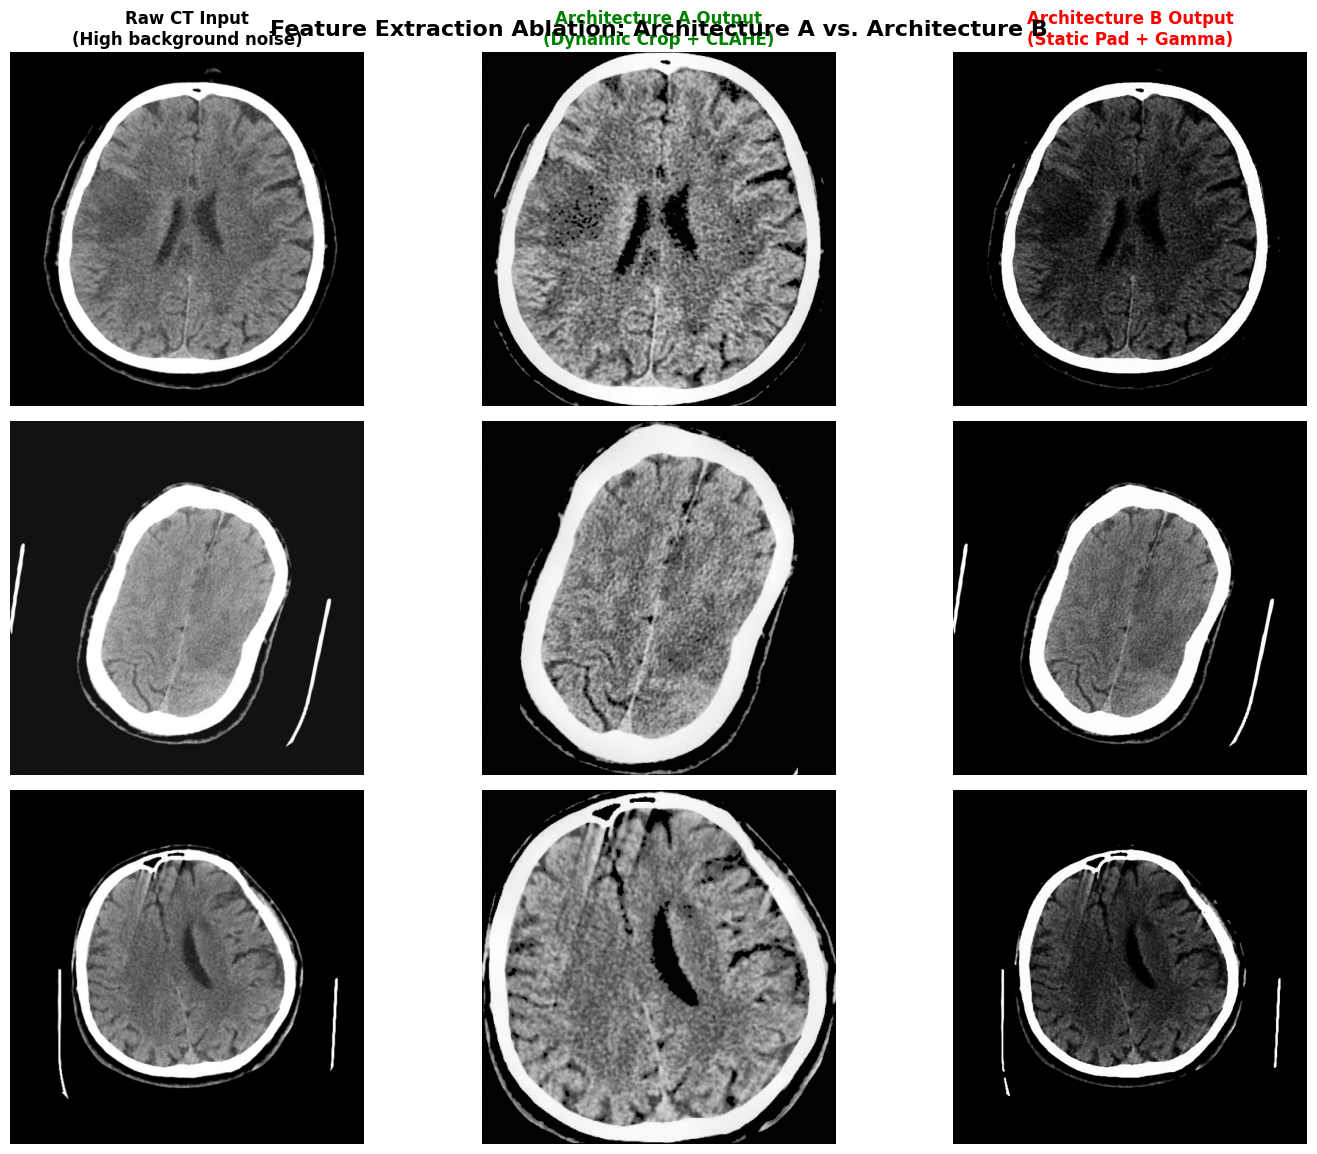

In [ ]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight

print("🔥 STARTING BENCHMARK MODEL 2: MobileNetV3 (Small) 🔥")
tf.keras.backend.clear_session()

# ==========================================
# 1. SETUP ISOLATED SAVE FOLDERS (Per User Request)
# ==========================================
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Neuro Project'
# This ensures MobileNet gets its own folder, totally separate from EfficientNet
CHECKPOINT_DIR_MBV3 = os.path.join(DRIVE_PROJECT_DIR, 'checkpoints', 'MobileNetV3')
os.makedirs(CHECKPOINT_DIR_MBV3, exist_ok=True)

MODEL_SAVE_PATH_MBV3 = os.path.join(CHECKPOINT_DIR_MBV3, 'mobilenetv3_cbam_best.keras')
WEIGHTS_SAVE_PATH_MBV3 = os.path.join(CHECKPOINT_DIR_MBV3, 'mobilenetv3_cbam_best.weights.h5')

# ==========================================
# 2. RELOAD DATASET (To fix Colab memory wipe)
# ==========================================
LOCAL_DATASET_DIR = '/content/dataset'
ZIP_PATH = os.path.join(DRIVE_PROJECT_DIR, 'Brain Stroke CT scan.v2i.folder.zip')

if not os.path.exists(LOCAL_DATASET_DIR):
    print("📦 Re-extracting dataset to local storage...")
    os.makedirs(LOCAL_DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_DATASET_DIR)

TRAIN_DIR = os.path.join(LOCAL_DATASET_DIR, 'train')
VAL_DIR = os.path.join(LOCAL_DATASET_DIR, 'valid')
TEST_DIR = os.path.join(LOCAL_DATASET_DIR, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("\nLoading Datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = tf.keras.utils.image_dataset_from_directory(VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = tf.keras.utils.image_dataset_from_directory(TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

# Recalculate Class Weights
labels = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print(f"✅ Weights Applied: {class_weight_dict}")

# ==========================================
# 3. CUSTOM ALGORITHMS (WITH CLAUDE'S LAMBDA FIX)
# ==========================================
def CBAM_Module(x, reduction_ratio=8):
    channels = x.shape[-1]

    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    dense_1 = layers.Dense(channels // reduction_ratio, activation='relu')
    dense_2 = layers.Dense(channels)
    channel_attention = layers.Activation('sigmoid')(layers.Add()([dense_2(dense_1(avg_pool)), dense_2(dense_1(max_pool))]))
    channel_attention = layers.Reshape((1, 1, channels))(channel_attention)
    x = layers.Multiply()([x, channel_attention])

    # Spatial Attention - THE CRITICAL FIX FOR SAVING/LOADING
    def pool_output_shape(input_shape):
        return input_shape[:-1] + (1,)

    avg_spatial = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True), output_shape=pool_output_shape)(x)
    max_spatial = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True), output_shape=pool_output_shape)(x)

    spatial_concat = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial_concat)
    return layers.Multiply()([x, spatial_attention])

class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        p_t = tf.math.exp(-ce_loss)
        return tf.math.pow((1.0 - p_t), self.gamma) * ce_loss

# ==========================================
# 4. BUILD ARCHITECTURE (With MobileNetV3)
# ==========================================
inputs = layers.Input(shape=(224, 224, 3), name="Raw_CT_Scan")

# Note: RandomContrast is REMOVED to protect preprocessing!
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)

# Lightweight MobileNet Backbone
base_model_mbv3 = MobileNetV3Small(include_top=False, input_tensor=x, weights='imagenet')
base_model_mbv3.trainable = False # Freeze for Phase 1

cbam_features = CBAM_Module(base_model_mbv3.output)
z = layers.GlobalAveragePooling2D()(cbam_features)
z = layers.Dense(128, activation='relu')(z)
z = layers.BatchNormalization()(z)
z = layers.Dropout(0.4)(z)
outputs = layers.Dense(3, activation='softmax', name="Diagnosis", dtype='float32')(z)

model_mbv3 = tf.keras.Model(inputs=inputs, outputs=outputs, name="NeuroScan_MobileNetV3")

# ==========================================
# 5. TWO-PHASE TRAINING LOOP
# ==========================================
print("\n🔥 PHASE 1: WARM-UP (Training Attention Head Only) 🔥")
model_mbv3.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
              loss=SparseCategoricalFocalLoss(gamma=2.0), metrics=["accuracy"])

history_phase1 = model_mbv3.fit(
    train_dataset, validation_data=val_dataset, epochs=5, class_weight=class_weight_dict
)

print("\n🔥 PHASE 2: FINE-TUNING (Unfreezing Backbone) 🔥")
base_model_mbv3.trainable = True

model_mbv3.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5),
              loss=SparseCategoricalFocalLoss(gamma=2.0), metrics=["accuracy"])

callbacks_list = [
    callbacks.ModelCheckpoint(MODEL_SAVE_PATH_MBV3, save_best_only=True, monitor="val_loss", mode="min", verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

history_phase2 = model_mbv3.fit(
    train_dataset, validation_data=val_dataset, epochs=30,
    callbacks=callbacks_list, class_weight=class_weight_dict
)

# Emergency Backup: Save raw weights explicitly to avoid any future deserialization traps
model_mbv3.save_weights(WEIGHTS_SAVE_PATH_MBV3)
print(f"\n✅ Training Complete! Full model and weights saved to: {CHECKPOINT_DIR_MBV3}")

#new

In [ ]:
import os
import shutil
import random

# Define your base dataset path in Drive
BASE_DIR = '/content/drive/MyDrive/Neuroscan/dataset'

# The three classes we care about
CLASSES = ['Normal', 'Ischemia', 'Bleeding']

# Where we want to put the organized images
NEW_DATASET_DIR = '/content/drive/MyDrive/Neuroscan/organized_dataset'
TRAIN_DIR = os.path.join(NEW_DATASET_DIR, 'Train')
VAL_DIR = os.path.join(NEW_DATASET_DIR, 'Validation')
TEST_DIR = os.path.join(NEW_DATASET_DIR, 'Test')

print("Starting dataset organization...")

# Create the new Train, Validation, and Test folders
for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in CLASSES:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

# Loop through each class, grab the PNGs, and split them
for cls in CLASSES:
    print(f"Processing class: {cls}...")

    # Path to the PNG folder inside your current setup
    png_folder = os.path.join(BASE_DIR, cls, 'PNG')

    if not os.path.exists(png_folder):
        print(f"  WARNING: Could not find PNG folder at {png_folder}")
        continue

    # Get all the .png (and .jpg) files
    images = [f for f in os.listdir(png_folder) if f.endswith('.png') or f.endswith('.jpg')]

    if not images:
        print(f"  No images found in {png_folder}")
        continue

    print(f"  Found {len(images)} images.")

    # Shuffle the images randomly
    random.shuffle(images)

    # Calculate the split (80% Train, 10% Validation, 10% Test)
    train_split_idx = int(len(images) * 0.8)
    val_split_idx = int(len(images) * 0.9)

    train_images = images[:train_split_idx]
    val_images = images[train_split_idx:val_split_idx]
    test_images = images[val_split_idx:]

    print(f"  Copying {len(train_images)} to Train, {len(val_images)} to Validation, {len(test_images)} to Test...")

    # Copy to Train folder
    for img in train_images:
        src = os.path.join(png_folder, img)
        dst = os.path.join(TRAIN_DIR, cls, img)
        if not os.path.exists(dst): # Only copy if it doesn't exist yet
            shutil.copy2(src, dst)

    # Copy to Validation folder
    for img in val_images:
        src = os.path.join(png_folder, img)
        dst = os.path.join(VAL_DIR, cls, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    # Copy to Test folder
    for img in test_images:
        src = os.path.join(png_folder, img)
        dst = os.path.join(TEST_DIR, cls, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

print("\nDataset Organization Complete!")
print(f"Your ready-to-train dataset is located at: {NEW_DATASET_DIR}")

Starting dataset organization...
Processing class: Normal...
  Found 4074 images.
  Copying 3259 to Train, 407 to Validation, 408 to Test...
Processing class: Ischemia...
  Found 1130 images.
  Copying 904 to Train, 113 to Validation, 113 to Test...
Processing class: Bleeding...
  Found 1093 images.
  Copying 874 to Train, 109 to Validation, 110 to Test...

Dataset Organization Complete!
Your ready-to-train dataset is located at: /content/drive/MyDrive/Neuroscan/organized_dataset


Checking GPU and Optimizing Resources...
✅ GPU Detected: Tesla T4
✅ Mixed Precision Enabled: Training will be faster and use less RAM.

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

⏳ Copying dataset from Google Drive to local Colab storage...
This will take a few minutes, but it will PERMANENTLY fix the 12GB RAM issue and make training much faster!
✅ Copy complete! System RAM is now safe.

Scanning for and removing corrupted/empty images...
✅ Removed 0 corrupted/empty images. Dataset is clean!
🧹 System RAM flushed and optimized.

Loading Training Data...
Found 6073 files belonging to 3 classes.

Loading Validation Data...
Found 1208 files belonging to 3 classes.

Loading Unseen Test Data...
Found 1194 files belonging to 3 classes.
✅ Classes detected: ['Bleeding', 'Ischemia', 'Normal']

✅ Found existing checkpoint at /content/drive/MyDrive/Neuroscan/checkpoints/neuroscan_be

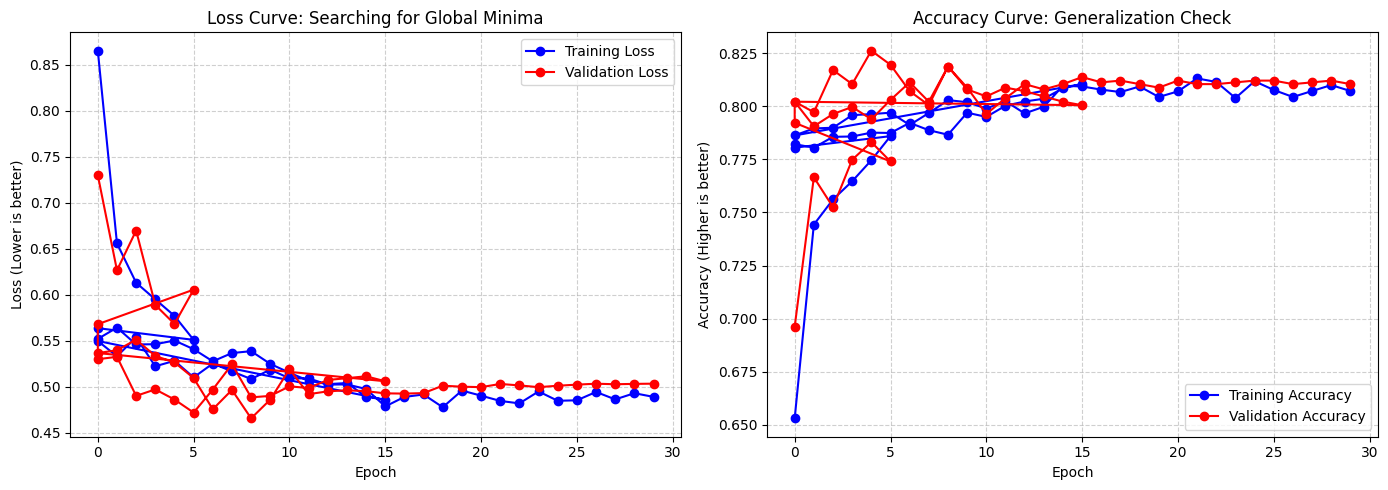

In [ ]:
import os
import gc # Garbage Collector to manually flush RAM
import shutil # Added to copy files to local disk
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
from PIL import Image

# ==========================================
# 1. GPU USAGE & COLAB OPTIMIZATIONS
# ==========================================
print("Checking GPU and Optimizing Resources...")
tf.keras.backend.clear_session()

# Check for GPU
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    details = tf.config.experimental.get_device_details(gpu_devices[0])
    print(f"✅ GPU Detected: {details.get('device_name', 'Unknown GPU')}")
else:
    print("⚠️ WARNING: No GPU detected! Go to Runtime > Change runtime type > Select T4 GPU.")

# Enable Mixed Precision to save 50% GPU memory
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed Precision Enabled: Training will be faster and use less RAM.")
except Exception as e:
    print("Mixed precision not supported on this specific setup, continuing normally.")

# ==========================================
# 2. MOUNT DRIVE & FIX GOOGLE DRIVE RAM LEAK
# ==========================================
print("\nConnecting to Google Drive...")
drive.mount('/content/drive')

# Your Drive Paths
BASE_DIR = '/content/drive/MyDrive/Neuroscan'
DRIVE_DATASET_DIR = os.path.join(BASE_DIR, 'organized_dataset')

# THE ULTIMATE RAM FIX: Copy files from Drive to Colab's local disk
# Reading thousands of files directly from Google Drive causes a massive RAM caching leak.
LOCAL_DATASET_DIR = '/content/local_dataset'

if not os.path.exists(LOCAL_DATASET_DIR):
    print("\n⏳ Copying dataset from Google Drive to local Colab storage...")
    print("This will take a few minutes, but it will PERMANENTLY fix the 12GB RAM issue and make training much faster!")
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print("✅ Copy complete! System RAM is now safe.")
else:
    print("\n✅ Dataset already exists on local storage.")

# Use the LOCAL paths for training so Google Drive doesn't crash the RAM
TRAIN_DIR = os.path.join(LOCAL_DATASET_DIR, 'Train')
VAL_DIR = os.path.join(LOCAL_DATASET_DIR, 'Validation')
TEST_DIR = os.path.join(LOCAL_DATASET_DIR, 'Test')

# Keep Checkpoints saving to Google Drive so you don't lose them!
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_best_model.keras')
LOG_PATH = os.path.join(CHECKPOINT_DIR, 'training_history.csv')

# ==========================================
# 2.5 CORRUPTED IMAGE SCANNER & RAM FLUSH
# ==========================================
print("\nScanning for and removing corrupted/empty images...")
corrupted_count = 0
for folder_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.exists(folder_path):
        continue
    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                if os.path.getsize(img_path) == 0:
                    os.remove(img_path)
                    corrupted_count += 1
                    continue
                with Image.open(img_path) as img:
                    img.verify()
            except Exception as e:
                print(f"Removing corrupted file: {img_path}")
                os.remove(img_path)
                corrupted_count += 1

print(f"✅ Removed {corrupted_count} corrupted/empty images. Dataset is clean!")

# Forcefully flush the System RAM after copying and scanning files
gc.collect()
print("🧹 System RAM flushed and optimized.")

# ==========================================
# 3. LOAD & STRICTLY OPTIMIZE DATASETS
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

print("\nLoading Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

print("\nLoading Validation Data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

print("\nLoading Unseen Test Data...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_dataset.class_names
print(f"✅ Classes detected: {class_names}")

# AGGRESSIVE RAM FIX: Hardcode buffer size to 2 instead of AUTOTUNE.
train_dataset = train_dataset.prefetch(buffer_size=2)
val_dataset = val_dataset.prefetch(buffer_size=2)
test_dataset = test_dataset.prefetch(buffer_size=2)

# ==========================================
# 4. BUILD AI ARCHITECTURE
# ==========================================
# Real-World Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="augmentation_layer")

if os.path.exists(CHECKPOINT_PATH):
    print(f"\n✅ Found existing checkpoint at {CHECKPOINT_PATH}")
    print("Resuming training from exactly where you left off!")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)
else:
    print("\n🚀 No checkpoint found. Starting fresh training!")

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)

    # Load lightweight EfficientNetB0 backbone
    base_model = EfficientNetB0(include_top=False, input_tensor=x, weights='imagenet')
    base_model.trainable = False # Freeze for initial training phase

    x = layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3, name="top_dropout")(x) # Prevent overfitting

    # Final decision layer. Needs dtype='float32' for mixed precision stability
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="pred", dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs, name="NeuroScan_EfficientNet")

    # AdamW Optimizer: Helps find the global minima efficiently
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

# ==========================================
# 5. CALLBACKS & TRAINING LOOP
# ==========================================
callbacks_list = [
    # Save the model only if validation accuracy improves
    callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
        verbose=1
    ),
    # Helps slide into the Global Minima by slowing down learning rate when stuck
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    # Logs history to a CSV to plot the graph later
    callbacks.CSVLogger(LOG_PATH, append=True)
]

print("\n🔥 Starting the Training Engine...")
print("📝 Press the 'Stop' button in Colab anytime to pause. Progress is auto-saved!")

try:
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=30, # Train for 30 epochs
        callbacks=callbacks_list,
        verbose=1
    )
except KeyboardInterrupt:
    print("\n🛑 Training paused by user! Your progress is safely saved in Drive.")

# ==========================================
# 6. FINAL METRICS, TESTING & GRAPH
# ==========================================
print("\n==========================================")
print("🧪 FINAL MODEL EVALUATION ON UNSEEN DATA")
print("==========================================")
if os.path.exists(CHECKPOINT_PATH):
    print("Loading your absolute best saved model for final test...")
    best_model = tf.keras.models.load_model(CHECKPOINT_PATH)
    test_loss, test_acc = best_model.evaluate(test_dataset)
    print(f"\n🏆 FINAL TEST ACCURACY: {test_acc*100:.2f}%")
    print(f"📉 FINAL TEST LOSS: {test_loss:.4f}\n")
else:
    print("No checkpoint found to evaluate.")

def plot_training_analysis(csv_path):
    if not os.path.exists(csv_path):
        return

    df = pd.read_csv(csv_path)
    if len(df) < 2:
        print("Not enough epochs completed to draw a graph yet.")
        return

    plt.figure(figsize=(14, 5))

    # Loss Graph (Checking for Global Minima)
    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['loss'], label='Training Loss', color='blue', marker='o')
    plt.plot(df['epoch'], df['val_loss'], label='Validation Loss', color='red', marker='o')
    plt.title('Loss Curve: Searching for Global Minima')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Lower is better)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Accuracy Graph
    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['accuracy'], label='Training Accuracy', color='blue', marker='o')
    plt.plot(df['epoch'], df['val_accuracy'], label='Validation Accuracy', color='red', marker='o')
    plt.title('Accuracy Curve: Generalization Check')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (Higher is better)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Generating Performance Graphs...")
plot_training_analysis(LOG_PATH)

## imporved

Checking GPU and Optimizing Resources...
✅ GPU Detected!
✅ Mixed Precision Enabled: RAM usage halved.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Local dataset already exists and looks complete.

Scanning for corrupted/empty images...
✅ Removed 0 corrupted images.

Loading Datasets...
Found 6073 files belonging to 3 classes.
Found 1208 files belonging to 3 classes.
Found 1194 files belonging to 3 classes.

Calculating Class Weights to prevent bias...
✅ Weights Applied: {0: np.float64(1.9151687164932198), 1: np.float64(1.8726487819919828), 2: np.float64(0.5144430326132995)}

🔄 Found checkpoint at /content/drive/MyDrive/Neuroscan/checkpoints/neuroscan_master_best.keras. Resuming training...

🔥 Starting the Training Engine...
📝 Press 'Stop' in Colab anytime to pause. Progress is auto-saved!
Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9829 - loss: 0.0120
Epoch 1: val_accuracy imp

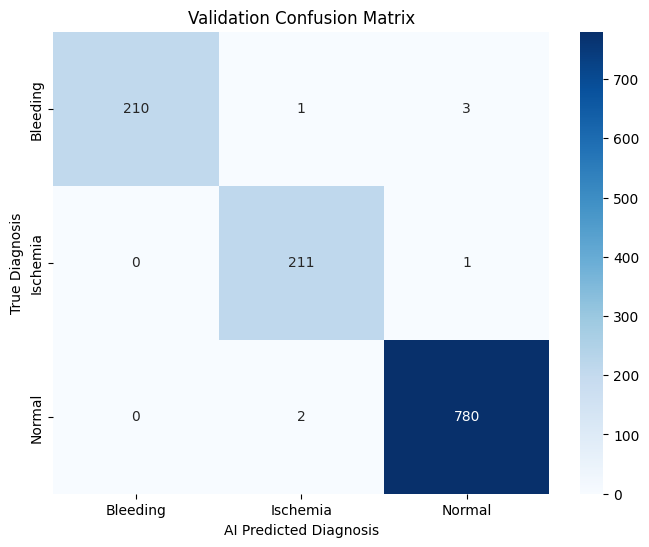

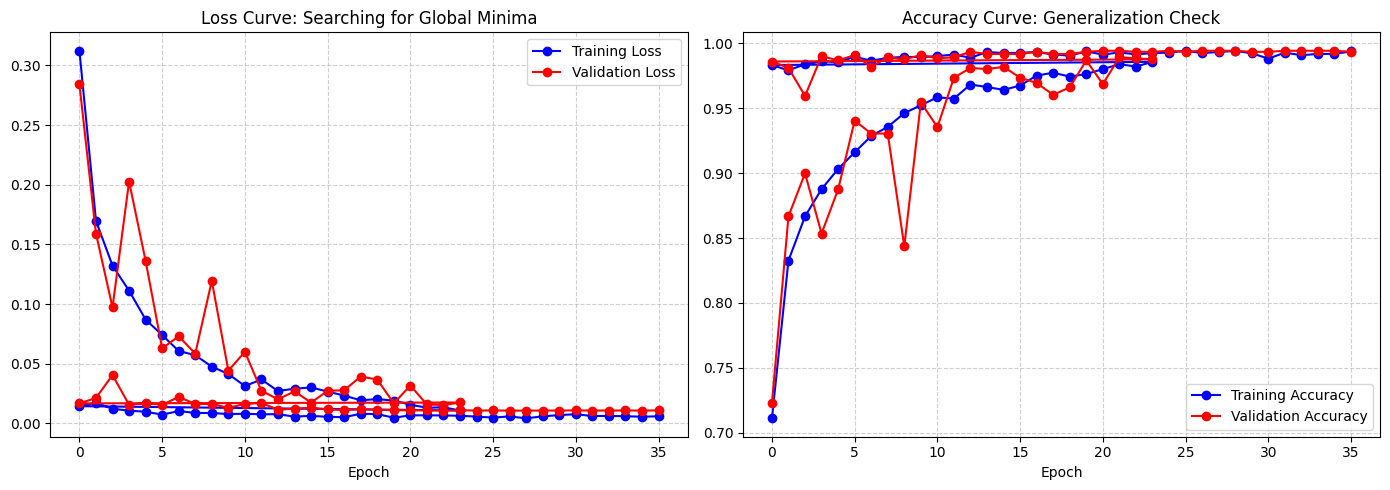


📦 Quantizing model to 8-bit TFLite for low-end hospital hardware...
Saved artifact at '/tmp/tmp3ubspp4t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='Raw_CT_Scan')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134278710240144: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  134280128066960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  134280128067728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280128069072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280128068688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280128069264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280128053712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280128069456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134278664815056: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# ==========================================
# 1. GPU USAGE & COLAB OPTIMIZATIONS
# ==========================================
print("Checking GPU and Optimizing Resources...")
tf.keras.backend.clear_session()

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ GPU Detected!")
else:
    print("⚠️ WARNING: No GPU detected! Use Runtime > Change runtime type > T4 GPU.")

try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed Precision Enabled: RAM usage halved.")
except:
    pass

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/Neuroscan'
DRIVE_DATASET_DIR = os.path.join(BASE_DIR, 'organized_dataset')
LOCAL_DATASET_DIR = '/content/local_dataset'
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_master_best.keras')
LOG_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_training_history.csv')
TFLITE_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_offline_8bit.tflite')

# ==========================================
# 2. LOCAL DATA MIGRATION & CORRUPTION SCANNER
# ==========================================
TRAIN_DIR = os.path.join(LOCAL_DATASET_DIR, 'Train')
VAL_DIR = os.path.join(LOCAL_DATASET_DIR, 'Validation')
TEST_DIR = os.path.join(LOCAL_DATASET_DIR, 'Test')

if not os.path.exists(TRAIN_DIR) or not os.path.exists(VAL_DIR):
    print("\n⏳ Incomplete local dataset detected. Forcing a fresh copy from Google Drive...")
    if os.path.exists(LOCAL_DATASET_DIR):
        shutil.rmtree(LOCAL_DATASET_DIR) # Delete the broken folder
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print("✅ Copy complete! System RAM is now safe.")
else:
    print("\n✅ Local dataset already exists and looks complete.")

print("\nScanning for corrupted/empty images...")
corrupted_count = 0
for folder_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.exists(folder_path): continue
    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir): continue
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                if os.path.getsize(img_path) == 0:
                    os.remove(img_path); corrupted_count += 1; continue
                with Image.open(img_path) as img:
                    img.verify()
            except:
                os.remove(img_path); corrupted_count += 1
print(f"✅ Removed {corrupted_count} corrupted images.")
gc.collect()

# ==========================================
# 3. LOAD & STRICTLY OPTIMIZE DATASETS
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("\nLoading Datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = tf.keras.utils.image_dataset_from_directory(VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = tf.keras.utils.image_dataset_from_directory(TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
class_names = train_dataset.class_names

train_dataset = train_dataset.prefetch(buffer_size=2)
val_dataset = val_dataset.prefetch(buffer_size=2)
test_dataset = test_dataset.prefetch(buffer_size=2)

print("\nCalculating Class Weights to prevent bias...")
# Extract labels efficiently for class weighting
labels = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print(f"✅ Weights Applied: {class_weight_dict}")

# ==========================================
# 4. CUSTOM ALGORITHMS (ECA & Focal Loss)
# ==========================================
def ECA_Module(x, k_size=3):
    """Efficient Channel Attention: Acts as a lightweight magnifying glass for tiny clots"""
    channels = x.shape[-1]
    y = layers.GlobalAveragePooling2D()(x)
    y = layers.Reshape((channels, 1))(y)
    y = layers.Conv1D(1, kernel_size=k_size, padding='same', activation='sigmoid')(y)
    y = layers.Reshape((1, 1, channels))(y)
    return layers.Multiply()([x, y])

class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    """Focal Loss: Forces the AI to focus on hard-to-detect Ischemic Strokes"""
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        p_t = tf.math.exp(-ce_loss)
        return tf.math.pow((1.0 - p_t), self.gamma) * ce_loss

# ==========================================
# 5. MULTI-SCALE ARCHITECTURE & RESUME LOGIC
# ==========================================
def build_neuroscan_model(num_classes=3):
    inputs = layers.Input(shape=(224, 224, 3), name="Raw_CT_Scan")

    # Built-in Augmentation & Enhancement
    x = layers.RandomContrast(0.2)(inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.1)(x)

    base_model = EfficientNetB0(include_top=False, input_tensor=x, weights='imagenet')
    base_model.trainable = True # Unfrozen for Deep Fine-Tuning

    # Multi-Scale Features
    try:
        shallow_features = base_model.get_layer('block3a_activation').output # Tiny clots
    except ValueError:
        shallow_features = base_model.layers[50].output
    deep_features = base_model.output # Massive bleeds

    # ECA Attention applied to deep features
    eca_features = ECA_Module(deep_features)

    shallow_pooled = layers.GlobalAveragePooling2D(name="Shallow_Pool")(shallow_features)
    deep_pooled = layers.GlobalAveragePooling2D(name="Deep_ECA_Pool")(eca_features)

    merged = layers.Concatenate(name="MultiScale_Fusion")([shallow_pooled, deep_pooled])

    z = layers.Dense(128, activation='relu')(merged)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)
    outputs = layers.Dense(num_classes, activation='softmax', name="Diagnosis", dtype='float32')(z)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="NeuroScan_Master")

EPOCHS = 50
TOTAL_STEPS = EPOCHS * len(train_dataset) # Calculate steps for Cosine Decay

if os.path.exists(CHECKPOINT_PATH):
    print(f"\n🔄 Found checkpoint at {CHECKPOINT_PATH}. Resuming training...")
    # MUST provide custom objects when loading!
    model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
else:
    print("\n🆕 Starting fresh Master Training...")
    model = build_neuroscan_model(len(class_names))

    # High-Accuracy Optimizer Setup: SGD + Nesterov Momentum + Cosine Decay
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.01, decay_steps=TOTAL_STEPS, alpha=0.001)
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9, nesterov=True)

    model.compile(optimizer=optimizer, loss=SparseCategoricalFocalLoss(gamma=2.0), metrics=["accuracy"])

# ==========================================
# 6. TRAINING LOOP
# ==========================================
callbacks_list = [
    callbacks.ModelCheckpoint(CHECKPOINT_PATH, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    callbacks.CSVLogger(LOG_PATH, append=True)
]

print("\n🔥 Starting the Training Engine...")
print("📝 Press 'Stop' in Colab anytime to pause. Progress is auto-saved!")

try:
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=callbacks_list, class_weight=class_weight_dict, verbose=1)
except KeyboardInterrupt:
    print("\n🛑 Training paused by user! Your progress is safely saved in Drive.")

# ==========================================
# 7. FINAL METRICS, TESTING & GRAPHS
# ==========================================
print("\n==========================================")
print("🧪 FINAL CLINICAL EVALUATION")
print("==========================================")

# Load best model for tests
best_model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})

test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"\n🏆 UNSEEN TEST ACCURACY: {test_acc*100:.2f}%")

# Generate Classification Report & Confusion Matrix
print("\n📊 Generating Clinical Metrics...")
y_true = []
y_pred_probs = []
for images, labels in val_dataset: # Using validation set for the matrix
    y_true.extend(labels.numpy())
    y_pred_probs.extend(best_model.predict(images, verbose=0))

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix')
plt.ylabel('True Diagnosis')
plt.xlabel('AI Predicted Diagnosis')
plt.show()

# Plot CSV Logs
try:
    df = pd.read_csv(LOG_PATH)
    if len(df) >= 2:
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.plot(df['epoch'], df['loss'], label='Training Loss', color='blue', marker='o')
        plt.plot(df['epoch'], df['val_loss'], label='Validation Loss', color='red', marker='o')
        plt.title('Loss Curve: Searching for Global Minima'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

        plt.subplot(1, 2, 2)
        plt.plot(df['epoch'], df['accuracy'], label='Training Accuracy', color='blue', marker='o')
        plt.plot(df['epoch'], df['val_accuracy'], label='Validation Accuracy', color='red', marker='o')
        plt.title('Accuracy Curve: Generalization Check'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Could not plot CSV history: {e}")

# ==========================================
# 8. POST-TRAINING QUANTIZATION (TFLITE)
# ==========================================
print("\n📦 Quantizing model to 8-bit TFLite for low-end hospital hardware...")
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

try:
    tflite_quant_model = converter.convert()
    with open(TFLITE_PATH, 'wb') as f:
        f.write(tflite_quant_model)

    orig_sz = os.path.getsize(CHECKPOINT_PATH) / (1024 * 1024)
    tf_sz = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
    print(f"✅ Quantization Successful!")
    print(f"📉 Original Model Size: {orig_sz:.2f} MB")
    print(f"📉 Compressed Offline Size: {tf_sz:.2f} MB")
    print(f"📁 TFLite model saved at: {TFLITE_PATH}")
except Exception as e:
    print(f"⚠️ Quantization failed: {e}")

## new arc


In [ ]:
import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

print("Checking GPU and Optimizing Resources...")
tf.keras.backend.clear_session()

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ GPU Detected!")
else:
    print("⚠️ WARNING: No GPU detected! Use Runtime > Change runtime type > T4 GPU.")

try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed Precision Enabled: RAM usage halved.")
except:
    pass

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/Neuroscan'
DRIVE_DATASET_DIR = os.path.join(BASE_DIR, 'organized_dataset')
LOCAL_DATASET_DIR = '/content/local_dataset'
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_master_best.keras')
LOG_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_training_history.csv')
TFLITE_PATH = os.path.join(CHECKPOINT_DIR, 'neuroscan_offline_8bit.tflite')

TRAIN_DIR = os.path.join(LOCAL_DATASET_DIR, 'Train')
VAL_DIR = os.path.join(LOCAL_DATASET_DIR, 'Validation')
TEST_DIR = os.path.join(LOCAL_DATASET_DIR, 'Test')

if not os.path.exists(TRAIN_DIR) or not os.path.exists(VAL_DIR):
    print("\n⏳ Incomplete local dataset detected. Copying fresh from Google Drive...")
    if os.path.exists(LOCAL_DATASET_DIR):
        shutil.rmtree(LOCAL_DATASET_DIR)
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print("✅ Copy complete!")

print("\nScanning for corrupted/empty images...")
corrupted_count = 0
for folder_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.exists(folder_path): continue
    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir): continue
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                if os.path.getsize(img_path) == 0:
                    os.remove(img_path); corrupted_count += 1; continue
                with Image.open(img_path) as img:
                    img.verify()
            except:
                os.remove(img_path); corrupted_count += 1
print(f"✅ Removed {corrupted_count} corrupted images.")
gc.collect()

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("\nLoading Datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = tf.keras.utils.image_dataset_from_directory(VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = tf.keras.utils.image_dataset_from_directory(TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
class_names = train_dataset.class_names

train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nCalculating Class Weights to prevent bias...")
labels = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print(f"✅ Weights Applied: {class_weight_dict}")

def CBAM_Module(x, reduction_ratio=8):
    """Convolutional Block Attention Module: Channel & Spatial Attention"""
    channels = x.shape[-1]

    # 1. Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    dense_1 = layers.Dense(channels // reduction_ratio, activation='relu')
    dense_2 = layers.Dense(channels)

    channel_avg = dense_2(dense_1(avg_pool))
    channel_max = dense_2(dense_1(max_pool))

    channel_attention = layers.Activation('sigmoid')(layers.Add()([channel_avg, channel_max]))
    channel_attention = layers.Reshape((1, 1, channels))(channel_attention)
    x = layers.Multiply()([x, channel_attention])

    # 2. Spatial Attention
    spatial_avg = tf.reduce_mean(x, axis=-1, keepdims=True)
    spatial_max = tf.reduce_max(x, axis=-1, keepdims=True)
    spatial_concat = layers.Concatenate(axis=-1)([spatial_avg, spatial_max])

    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial_concat)
    x = layers.Multiply()([x, spatial_attention])

    return x

class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    """Focal Loss: Forces model focus on difficult ischemic strokes"""
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        p_t = tf.math.exp(-ce_loss)
        return tf.math.pow((1.0 - p_t), self.gamma) * ce_loss

def build_neuroscan_model(num_classes=3):
    inputs = layers.Input(shape=(224, 224, 3), name="Raw_CT_Scan")

    x = layers.RandomContrast(0.2)(inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.1)(x)

    base_model = EfficientNetB0(include_top=False, input_tensor=x, weights='imagenet')
    base_model.trainable = True

    try:
        shallow_features = base_model.get_layer('block3a_activation').output
    except ValueError:
        shallow_features = base_model.layers[50].output
    deep_features = base_model.output

    cbam_features = CBAM_Module(deep_features)

    shallow_pooled = layers.GlobalAveragePooling2D(name="Shallow_Pool")(shallow_features)
    deep_pooled = layers.GlobalAveragePooling2D(name="Deep_CBAM_Pool")(cbam_features)

    merged = layers.Concatenate(name="MultiScale_Fusion")([shallow_pooled, deep_pooled])

    z = layers.Dense(128, activation='relu')(merged)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)
    outputs = layers.Dense(num_classes, activation='softmax', name="Diagnosis", dtype='float32')(z)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="NeuroScan_Master")

EPOCHS = 50
TOTAL_STEPS = EPOCHS * len(train_dataset)

if os.path.exists(CHECKPOINT_PATH):
    print(f"\n🔄 Resuming from checkpoint: {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
else:
    print("\n🆕 Starting fresh Master Training...")
    model = build_neuroscan_model(len(class_names))

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.01, decay_steps=TOTAL_STEPS, alpha=0.001)
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9, nesterov=True)

    model.compile(optimizer=optimizer, loss=SparseCategoricalFocalLoss(gamma=2.0), metrics=["accuracy"])

callbacks_list = [
    callbacks.ModelCheckpoint(CHECKPOINT_PATH, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    callbacks.CSVLogger(LOG_PATH, append=True)
]

print("\n🔥 Training Engine Active...")
try:
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=callbacks_list, class_weight=class_weight_dict, verbose=1)
except KeyboardInterrupt:
    print("\n🛑 Training paused by user. Progress safely saved in Drive.")

print("\n==========================================")
print("🧪 FINAL CLINICAL EVALUATION")
print("==========================================")

best_model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={"SparseCategoricalFocalLoss": SparseCategoricalFocalLoss})
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"\n🏆 UNSEEN TEST ACCURACY: {test_acc*100:.2f}%")

# Quantization to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f: f.write(tflite_model)

tflite_size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
print(f"\n✅ 8-bit Offline Model successfully saved at {TFLITE_PATH}")
print(f"📦 Model File Size: {tflite_size_mb:.2f} MB")


Checking GPU and Optimizing Resources...
✅ GPU Detected!
✅ Mixed Precision Enabled: RAM usage halved.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

⏳ Incomplete local dataset detected. Copying fresh from Google Drive...
✅ Copy complete!

Scanning for corrupted/empty images...
✅ Removed 0 corrupted images.

Loading Datasets...
Found 6073 files belonging to 3 classes.
Found 1208 files belonging to 3 classes.
Found 1194 files belonging to 3 classes.

Calculating Class Weights to prevent bias...
✅ Weights Applied: {0: np.float64(1.9151687164932198), 1: np.float64(1.8726487819919828), 2: np.float64(0.5144430326132995)}

🔄 Resuming from checkpoint: /content/drive/MyDrive/Neuroscan/checkpoints/neuroscan_master_best.keras

🔥 Training Engine Active...
Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9935 - loss: 0.0048
Epoch 1: val_accuracy improved from None to 0.99421, saving model to /conte